In [ ]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install polars pyarrow

In [ ]:
import polars as pl
path = "/content/drive/MyDrive/data/HI-Medium_Master.parquet"

In [ ]:
df = pl.read_parquet(path)
df.head()

Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Amount_Received_USD,Amount_Paid_USD,Sender_Entity,Sender_Bank_Name,Receiver_Entity,Receiver_Bank_Name
str,i64,str,i64,str,f64,str,f64,str,str,i64,f64,f64,str,str,str,str
"""2022/09/01 00:09""",1313,"""803E47FD0""",181605,"""8249FE0E0""",96289.46,"""US Dollar""",96289.46,"""US Dollar""","""Cheque""",0,96289.46,96289.46,"""Corporation #6642""","""Savings Bank of Indianapolis""","""Partnership #37115""","""First Bank of Boston"""
"""2022/09/01 00:03""",1313,"""803E47FD0""",181605,"""8249FE0E0""",19780.24,"""US Dollar""",19780.24,"""US Dollar""","""Credit Card""",0,19780.24,19780.24,"""Corporation #6642""","""Savings Bank of Indianapolis""","""Partnership #37115""","""First Bank of Boston"""
"""2022/09/01 00:14""",1313,"""803E47FD0""",181605,"""8249FE0E0""",65287.84,"""US Dollar""",65287.84,"""US Dollar""","""Cash""",0,65287.84,65287.84,"""Corporation #6642""","""Savings Bank of Indianapolis""","""Partnership #37115""","""First Bank of Boston"""
"""2022/09/01 00:01""",1313,"""803E47FD0""",181605,"""8249FE0E0""",6554.4,"""US Dollar""",6554.4,"""US Dollar""","""ACH""",0,6554.4,6554.4,"""Corporation #6642""","""Savings Bank of Indianapolis""","""Partnership #37115""","""First Bank of Boston"""
"""2022/09/01 00:05""",1313,"""803E47FD0""",181605,"""8249FE0E0""",4242.09,"""US Dollar""",4242.09,"""US Dollar""","""Wire""",0,4242.09,4242.09,"""Corporation #6642""","""Savings Bank of Indianapolis""","""Partnership #37115""","""First Bank of Boston"""


In [ ]:
df = pl.scan_parquet(path)   # lazy

In [ ]:
df.schema

/tmp/ipython-input-3182147272.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  df.schema


Schema([('Timestamp', String),
        ('From Bank', Int64),
        ('From Account', String),
        ('To Bank', Int64),
        ('To Account', String),
        ('Amount Received', Float64),
        ('Receiving Currency', String),
        ('Amount Paid', Float64),
        ('Payment Currency', String),
        ('Payment Format', String),
        ('Is Laundering', Int64),
        ('Amount_Received_USD', Float64),
        ('Amount_Paid_USD', Float64),
        ('Sender_Entity', String),
        ('Sender_Bank_Name', String),
        ('Receiver_Entity', String),
        ('Receiver_Bank_Name', String)])

In [ ]:
# bank 개수

import polars as pl

# 1. From Bank와 To Bank의 유니크 리스트 각각 추출
# 2. 두 리스트를 합쳐서(Union) 전체 유니크 은행 개수 계산
bank_stats = (
    df.select([
        pl.col("From Bank").n_unique().alias("unique_from_banks"),
        pl.col("To Bank").n_unique().alias("unique_to_banks"),
        # 전체(From + To) 유니크 개수를 구하기 위해 두 컬럼을 합친 후 카운트
        pl.concat_list([pl.col("From Bank"), pl.col("To Bank")])
          .flatten()
          .n_unique()
          .alias("total_unique_banks")
    ])
    .collect()
)

print("--- [은행 네트워크 규모 확인] ---")
print(bank_stats)

--- [은행 네트워크 규모 확인] ---
shape: (1, 3)
┌───────────────────┬─────────────────┬────────────────────┐
│ unique_from_banks ┆ unique_to_banks ┆ total_unique_banks │
│ ---               ┆ ---             ┆ ---                │
│ u32               ┆ u32             ┆ u32                │
╞═══════════════════╪═════════════════╪════════════════════╡
│ 122330            ┆ 62820           ┆ 122333             │
└───────────────────┴─────────────────┴────────────────────┘


In [ ]:
import polars as pl

# 1. 송신 은행, 수신 은행, 그리고 전체 통합 유니크 개수 계산
bank_name_stats = (
    df.select([
        pl.col("Sender_Bank_Name").n_unique().alias("unique_sender_banks"),
        pl.col("Receiver_Bank_Name").n_unique().alias("unique_receiver_banks"),
        # 두 컬럼을 하나로 합쳐서 전체 유니크 은행 이름 개수 산출
        pl.concat_list([pl.col("Sender_Bank_Name"), pl.col("Receiver_Bank_Name")])
          .flatten()
          .n_unique()
          .alias("total_unique_bank_names")
    ])
    .collect()
)

print("--- [은행 이름 기준 네트워크 규모] ---")
print(bank_name_stats)

--- [은행 이름 기준 네트워크 규모] ---
shape: (1, 3)
┌─────────────────────┬───────────────────────┬─────────────────────────┐
│ unique_sender_banks ┆ unique_receiver_banks ┆ total_unique_bank_names │
│ ---                 ┆ ---                   ┆ ---                     │
│ u32                 ┆ u32                   ┆ u32                     │
╞═════════════════════╪═══════════════════════╪═════════════════════════╡
│ 80179               ┆ 41882                 ┆ 80180                   │
└─────────────────────┴───────────────────────┴─────────────────────────┘


In [ ]:
df = df.with_columns(
    pl.col("Timestamp").str.to_datetime()
)

In [ ]:
df.schema

/tmp/ipython-input-3182147272.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  df.schema


Schema([('Timestamp', Datetime(time_unit='us', time_zone=None)),
        ('From Bank', Int64),
        ('From Account', String),
        ('To Bank', Int64),
        ('To Account', String),
        ('Amount Received', Float64),
        ('Receiving Currency', String),
        ('Amount Paid', Float64),
        ('Payment Currency', String),
        ('Payment Format', String),
        ('Is Laundering', Int64),
        ('Amount_Received_USD', Float64),
        ('Amount_Paid_USD', Float64),
        ('Sender_Entity', String),
        ('Sender_Bank_Name', String),
        ('Receiver_Entity', String),
        ('Receiver_Bank_Name', String)])

In [ ]:
# 1. 정상거래vs사기거래 비율
ratio = (
    df.group_by("Is Laundering")
    .count()
    .with_columns(
        (pl.col("count") / pl.col("count").sum() * 100).alias("ratio_%")
    )
)

ratio.collect()

/tmp/ipython-input-681215754.py:4: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


Is Laundering,count,ratio_%
i64,u32,f64
1,35230,0.110443
0,31863439,99.889557


/tmp/ipython-input-4267041860.py:5: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


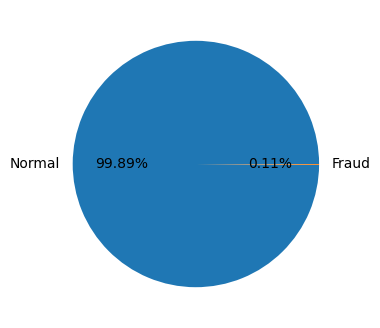

In [ ]:
import matplotlib.pyplot as plt

plot_df = (
    df.group_by("Is Laundering")
    .count()
    .collect()
    .to_pandas()
)

plt.figure(figsize=(4,4))
plt.pie(plot_df["count"], labels=["Normal","Fraud"], autopct="%1.2f%%")
plt.show()


In [ ]:
#2. 거래 금액 분포 비교
df.group_by("Is Laundering").agg([
    pl.col("Amount_Paid_USD").count().alias("count"),
    pl.col("Amount_Paid_USD").mean().alias("mean"),
    pl.col("Amount_Paid_USD").std().alias("std"),
    pl.col("Amount_Paid_USD").min().alias("min"),
    pl.col("Amount_Paid_USD").median().alias("median"),
    pl.col("Amount_Paid_USD").max().alias("max"),
]).collect()


Is Laundering,count,mean,std,min,median,max
i64,u32,f64,f64,f64,f64,f64
0,31863439,334778.937986,5.3151e7,0.00007,841.11,1.5888e11
1,35230,3.7342e6,1.1788e8,0.12342,6041.00635,1.5414e10


In [ ]:
plot_df = (
    df.select("Is Laundering", "Amount_Paid_USD")
    .collect()
    .to_pandas()
)


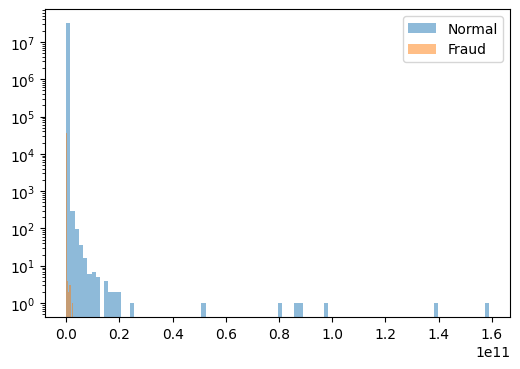

In [ ]:
import matplotlib.pyplot as plt

fraud = plot_df[plot_df["Is Laundering"] == 1]["Amount_Paid_USD"]
normal = plot_df[plot_df["Is Laundering"] == 0]["Amount_Paid_USD"]

plt.figure(figsize=(6,4))

plt.hist(normal, bins=100, alpha=0.5, label="Normal")
plt.hist(fraud, bins=100, alpha=0.5, label="Fraud")

plt.yscale("log")
plt.legend()
plt.show()


/tmp/ipython-input-6463374.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


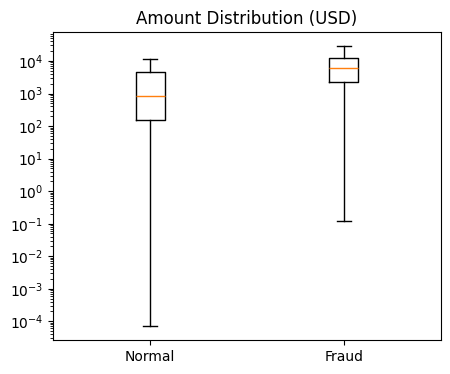

In [ ]:
import matplotlib.pyplot as plt

fraud = plot_df[plot_df["Is Laundering"] == 1]["Amount_Paid_USD"]
normal = plot_df[plot_df["Is Laundering"] == 0]["Amount_Paid_USD"]

plt.figure(figsize=(5,4))

plt.boxplot(
    [normal, fraud],
    labels=["Normal", "Fraud"],
    showfliers=False
)

plt.yscale("log")
plt.title("Amount Distribution (USD)")
plt.show()


/tmp/ipython-input-3880248300.py:7: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


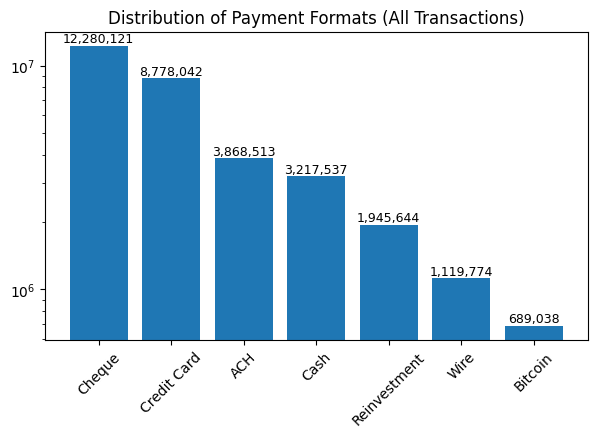

In [ ]:
#3. 결제 수단별 사기 빈도
#3-1 전체거래
import matplotlib.pyplot as plt

pf_all = (
    df.group_by("Payment Format")
    .count()
    .collect()
    .sort("count", descending=True)
    .to_pandas()
)

plt.figure(figsize=(7,4))

bars = plt.bar(
    pf_all["Payment Format"],
    pf_all["count"]
)

plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Distribution of Payment Formats (All Transactions)")

# 라벨 추가
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{int(y):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()



/tmp/ipython-input-942646191.py:8: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


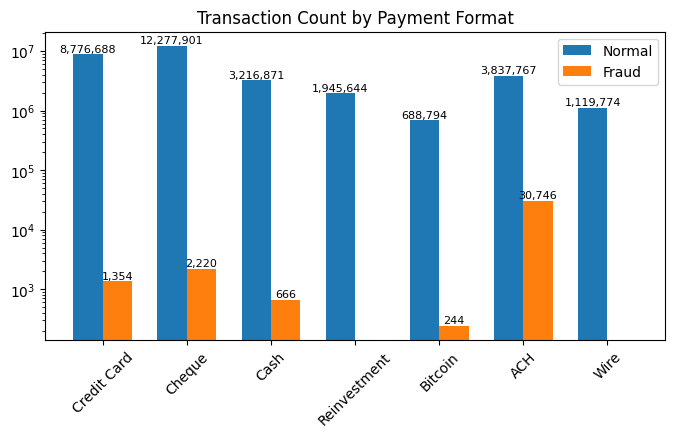

In [ ]:
#3-2 정상 vs 사기

import numpy as np
import matplotlib.pyplot as plt

pf_split = (
    df.group_by(["Payment Format", "Is Laundering"])
    .count()
    .collect()
    .to_pandas()
)

formats = pf_split["Payment Format"].unique()

normal = [
    pf_split[
        (pf_split["Payment Format"] == f) &
        (pf_split["Is Laundering"] == 0)
    ]["count"].sum()
    for f in formats
]

fraud = [
    pf_split[
        (pf_split["Payment Format"] == f) &
        (pf_split["Is Laundering"] == 1)
    ]["count"].sum()
    for f in formats
]

x = np.arange(len(formats))
w = 0.35

plt.figure(figsize=(8,4))

bars1 = plt.bar(x - w/2, normal, width=w, label="Normal")
bars2 = plt.bar(x + w/2, fraud, width=w, label="Fraud")

plt.yscale("log")
plt.xticks(x, formats, rotation=45)
plt.legend()
plt.title("Transaction Count by Payment Format")

# 라벨
for bars in [bars1, bars2]:
    for bar in bars:
        y = bar.get_height()
        if y > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                y,
                f"{int(y):,}",
                ha="center",
                va="bottom",
                fontsize=8
            )

plt.show()

/tmp/ipython-input-4000515558.py:5: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


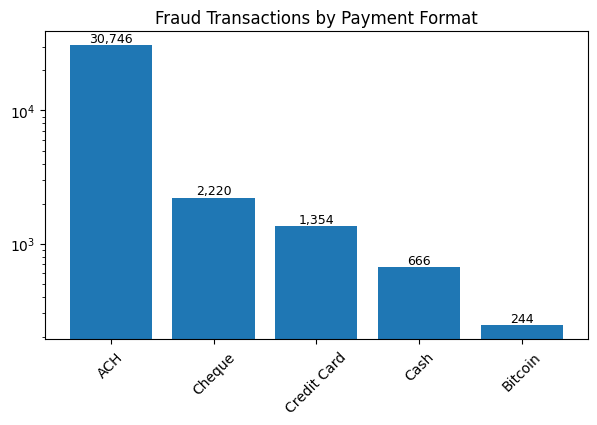

In [ ]:
#3-3 사기
pf_fraud = (
    df.filter(pl.col("Is Laundering") == 1)
    .group_by("Payment Format")
    .count()
    .collect()
    .sort("count", descending=True)
    .to_pandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

bars = plt.bar(
    pf_fraud["Payment Format"],
    pf_fraud["count"]
)

plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Fraud Transactions by Payment Format")

# 라벨
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{int(y):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()



/tmp/ipython-input-3972406583.py:6: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


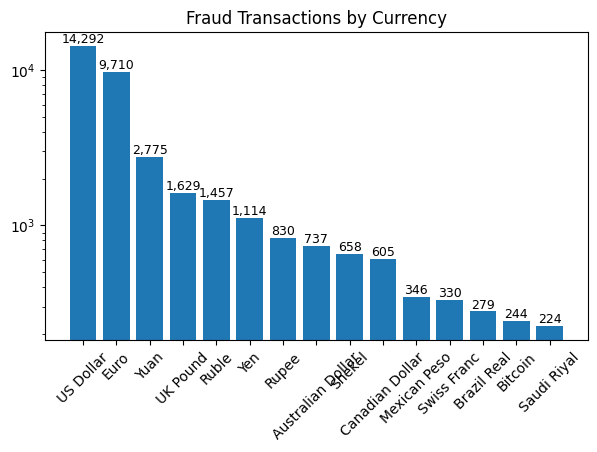

In [ ]:
# 4. 화폐별 사기 빈도
# 송금기준
currency_fraud = (
    df.filter(pl.col("Is Laundering") == 1)
    .group_by("Payment Currency")
    .count()
    .collect()
    .sort("count", descending=True)
    .to_pandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

bars = plt.bar(
    currency_fraud["Payment Currency"],
    currency_fraud["count"]
)

plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Fraud Transactions by Currency")

# 라벨
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{int(y):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()


/tmp/ipython-input-1166826836.py:5: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


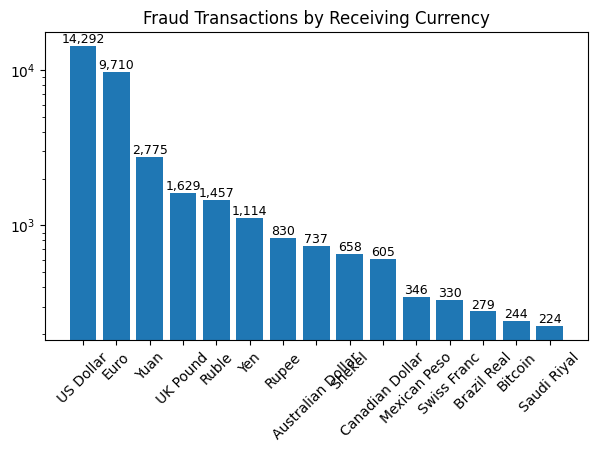

In [ ]:
#4-2 수금 기준
rcv_currency_fraud = (
    df.filter(pl.col("Is Laundering") == 1)
    .group_by("Receiving Currency")
    .count()
    .collect()
    .sort("count", descending=True)
    .to_pandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

bars = plt.bar(
    rcv_currency_fraud["Receiving Currency"],
    rcv_currency_fraud["count"]
)

plt.yscale("log")
plt.xticks(rotation=45)
plt.title("Fraud Transactions by Receiving Currency")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{int(y):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()



/tmp/ipython-input-2237107919.py:5: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


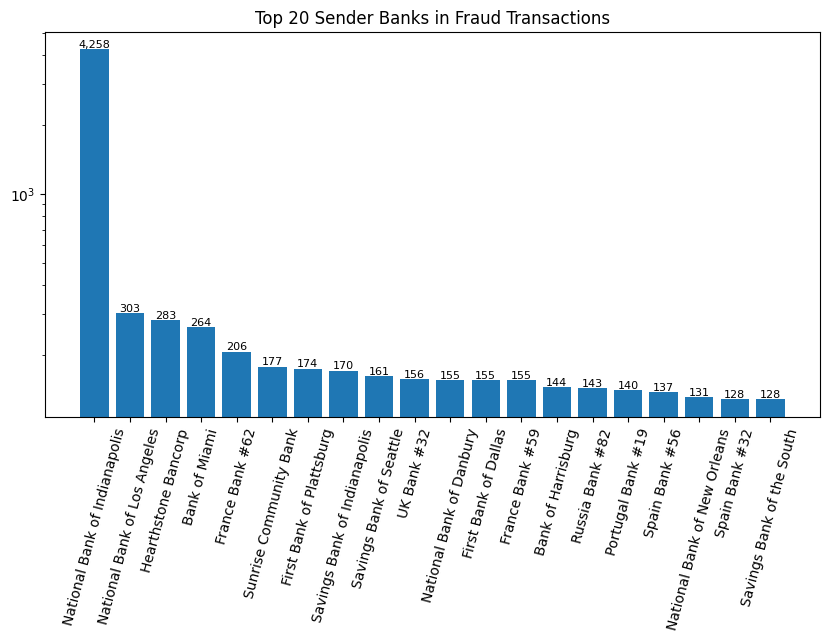

In [ ]:
#5. 사기에 이용된 송금 은행
bank_fraud_top20 = (
    df.filter(pl.col("Is Laundering") == 1)
    .group_by("Sender_Bank_Name")
    .count()
    .collect()
    .sort("count", descending=True)
    .head(20)
    .to_pandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(
    bank_fraud_top20["Sender_Bank_Name"],
    bank_fraud_top20["count"]
)

plt.yscale("log")
plt.xticks(rotation=75)
plt.title("Top 20 Sender Banks in Fraud Transactions")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{int(y):,}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.show()


/tmp/ipython-input-3987802783.py:6: DeprecationWarning: `count` was renamed; use `len` instead
  .count()


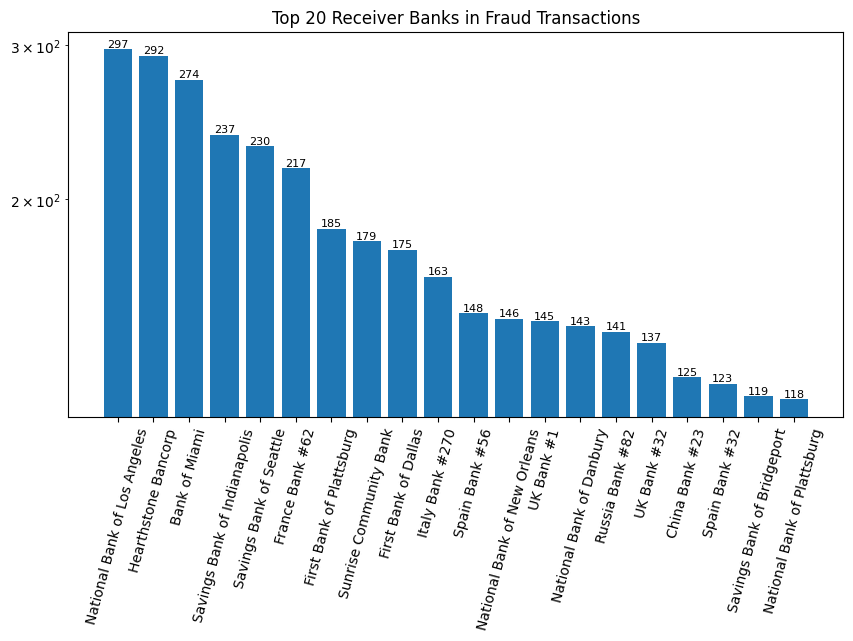

In [ ]:
#5-2. 사기에 이용된 수금 은행

bank_recv_fraud_top20 = (
    df.filter(pl.col("Is Laundering") == 1)
    .group_by("Receiver_Bank_Name")
    .count()
    .collect()
    .sort("count", descending=True)
    .head(20)
    .to_pandas()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

bars = plt.bar(
    bank_recv_fraud_top20["Receiver_Bank_Name"],
    bank_recv_fraud_top20["count"]
)

plt.yscale("log")
plt.xticks(rotation=75)
plt.title("Top 20 Receiver Banks in Fraud Transactions")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{int(y):,}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.show()


In [ ]:
#5-3  Risk Ranking → 사기율 높은 송금 은행

risk_rank = (
    df.group_by("From Bank")
    .agg([
        pl.count().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count") * 100)
        .alias("Fraud_Rate(%)")
    )
    .filter(pl.col("Fraud_Count") > 0)   # 사기 없는 은행 제외
    .sort("Fraud_Rate(%)", descending=True)
    .collect()
)

risk_rank.head(10)


/tmp/ipython-input-4276039103.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("Total_Count"),


From Bank,Total_Count,Fraud_Count,Fraud_Rate(%)
i64,u32,i64,f64
1215649,5,1,20.0
2201390,5,1,20.0
222602,6,1,16.666667
166899,7,1,14.285714
1139586,63,8,12.698413
221200,9,1,11.111111
3136606,12,1,8.333333
2208272,29,2,6.896552
210346,16,1,6.25


In [ ]:
# 5-3 Risk Ranking → 사기율 높은 송금 은행 (이름 기준)
risk_rank = (
    df.group_by("Sender_Bank_Name") # From Bank 대신 은행 이름으로 그룹화
    .agg([
        pl.len().alias("Total_Count"), # pl.count() 보단 최신 버전에서 권장되는 pl.len() 사용
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count"))
        .alias("Fraud_Rate(%)")
    )
    .filter(pl.col("Fraud_Count") > 0)   # 사기 거래가 최소 1건이라도 있는 은행만
    .sort("Fraud_Rate(%)", descending=True) # 사기율 높은 순으로 정렬
    .collect()
)

# 결과 확인
risk_rank.head(10)

Sender_Bank_Name,Total_Count,Fraud_Count,Fraud_Rate(%)
str,u32,i64,f64
"""Israel Bank #3111""",5,1,0.2
"""China Bank #4854""",5,1,0.2
"""India Bank #1852""",7,1,0.142857
"""Australia Bank #204""",63,8,0.126984
"""Austria Bank #11627""",16,1,0.0625
"""Russia Bank #2430""",16,1,0.0625
"""Canada Bank #1922""",22,1,0.045455
"""Italy Bank #15212""",22,1,0.045455
"""France Bank #2818""",50,2,0.04


In [ ]:
#5-3  Risk Ranking → 사기율 높은 수금 은행

risk_rank_recv = (
    df.group_by("To Bank")
    .agg([
        pl.count().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count"))
        .alias("Fraud_Rate(%)")
    )
    .filter(pl.col("Fraud_Count") > 0)
    .sort("Fraud_Rate(%)", descending=True)
    .collect()
)

risk_rank_recv.head(10)


/tmp/ipython-input-3909310100.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("Total_Count"),


To Bank,Total_Count,Fraud_Count,Fraud_Rate(%)
i64,u32,i64,f64
2225287,1,1,1.0
2205665,17,1,0.058824
1139586,276,9,0.032609
1222519,37,1,0.027027
1215649,58,1,0.017241
221200,69,1,0.014493
99677,4873,57,0.011697
219399,86,1,0.011628
272142,13005,141,0.010842


In [ ]:
# 코드 기준으로 정확히 집계하되, 이름만 옆에 붙여주는 방식
risk_rank_recv_fixed = (
    df.group_by("To Bank")
    .agg([
        pl.col("Receiver_Bank_Name").first().alias("Bank_Name"), # 해당 코드의 대표 이름
        pl.len().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count") * 100).alias("Fraud_Rate(%)")
    )
    .filter(pl.col("Fraud_Count") > 0)
    .sort("Fraud_Rate(%)", descending=True)
    .select(["Bank_Name", "Total_Count", "Fraud_Count", "Fraud_Rate(%)"]) # 이름 위주로 출력
    .collect()
)
risk_rank_recv_fixed.head(10)

Bank_Name,Total_Count,Fraud_Count,Fraud_Rate(%)
str,u32,i64,f64
"""Brownstone Savings Bank""",1,1,100.0
"""India Bank #1869""",17,1,5.882353
"""Australia Bank #204""",276,9,3.26087
"""Heath Savings Bank""",37,1,2.702703
"""China Bank #4854""",58,1,1.724138
"""National Bank of Boston""",69,1,1.449275
"""UK Bank #144""",4873,57,1.169711
"""Italy Bank #12734""",86,1,1.162791
"""Russia Bank #82""",13005,141,1.084198


In [ ]:
#5-4 Volume Ranking → 사기 건수 많은 송금 은행


volume_rank = (
    df.group_by("From Bank")
    .agg([
        pl.count().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count"))
        .alias("Fraud_Rate")
    )
    .sort("Fraud_Count", descending=True)
    .collect()
)

volume_rank.head(10)


/tmp/ipython-input-1611497172.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("Total_Count"),


From Bank,Total_Count,Fraud_Count,Fraud_Rate
i64,u32,i64,f64
70,2960807,4190,0.001415
20,157093,300,0.00191
0,159908,280,0.001751
11,164584,254,0.001543
12,166485,206,0.001237
6,75996,156,0.002053
1,57024,155,0.002718
2310,75445,150,0.001988
272142,16169,143,0.008844


In [ ]:
# 5-4 Volume Ranking → 사기 건수 많은 송금 은행
volume_rank = (
    df.group_by("From Bank") # 코드로 정확하게 그룹핑
    .agg([
        pl.col("Sender_Bank_Name").first().alias("Bank_Name"), # 해당 코드의 대표 이름
        pl.len().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count") * 100).alias("Fraud_Rate(%)")
    )
    .sort("Fraud_Count", descending=True) # 건수 기준 내림차순
    .select(["Bank_Name", "Total_Count","Fraud_Count",  "Fraud_Rate(%)"]) # 보기 좋게 정렬
    .collect()
)

volume_rank.head(10)

Bank_Name,Total_Count,Fraud_Count,Fraud_Rate(%)
str,u32,i64,f64
"""National Bank of Indianapolis""",2960807,4190,0.141515
"""National Bank of Los Angeles""",157093,300,0.19097
"""Hearthstone Bancorp""",159908,280,0.175101
"""Bank of Miami""",164584,254,0.154328
"""France Bank #62""",166485,206,0.123735
"""UK Bank #32""",75996,156,0.205274
"""France Bank #59""",57024,155,0.271815
"""Sunrise Community Bank""",75445,150,0.19882
"""Russia Bank #82""",16169,143,0.884408


In [ ]:
#5-4 Volume Ranking → 사기 건수 많은 수금 은행

volume_rank_recv = (
    df.group_by("To Bank")
    .agg([
        pl.count().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count") * 100)
        .alias("Fraud_Rate(%)")
    )
    .sort("Fraud_Count", descending=True)
    .collect()
)

volume_rank_recv.head(10)


/tmp/ipython-input-920548513.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("Total_Count"),


To Bank,Total_Count,Fraud_Count,Fraud_Rate(%)
i64,u32,i64,f64
0,61262,287,0.46848
20,58812,287,0.487996
11,71382,264,0.369841
12,74056,217,0.293021
1213,23125,163,0.704865
2310,33197,156,0.469922
3,38245,148,0.386979
27,84133,145,0.172346
272142,13005,141,1.084198


In [ ]:
# 5-4 Volume Ranking → 사기 건수 많은 수금 은행
volume_rank_recv = (
    df.group_by("To Bank") # 수신 은행 코드로 그룹핑
    .agg([
        pl.col("Receiver_Bank_Name").first().alias("Bank_Name"), # 대표 이름 추출
        pl.len().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count") * 100).alias("Fraud_Rate(%)")
    )
    .sort("Fraud_Count", descending=True) # 사기 건수 기준 정렬
    .select(["Bank_Name", "Total_Count","Fraud_Count",  "Fraud_Rate(%)"])
    .collect()
)

volume_rank_recv.head(10)

Bank_Name,Total_Count,Fraud_Count,Fraud_Rate(%)
str,u32,i64,f64
"""Hearthstone Bancorp""",61262,287,0.46848
"""National Bank of Los Angeles""",58812,287,0.487996
"""Bank of Miami""",71382,264,0.369841
"""France Bank #62""",74056,217,0.293021
"""Italy Bank #270""",23125,163,0.704865
"""Sunrise Community Bank""",33197,156,0.469922
"""Spain Bank #56""",38245,148,0.386979
"""UK Bank #1""",84133,145,0.172346
"""Russia Bank #82""",13005,141,1.084198


In [ ]:
# 1. 송신(From) 은행: 사기 건수 + 사기율 (건수 100개 이상 필터링)


# 송신 은행 분석
from_bank_heavy = (
    df.group_by("From Bank")
    .agg([
        pl.col("Sender_Bank_Name").first().alias("Bank_Name"),
        pl.len().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count") * 100).alias("Fraud_Rate(%)")
    )
    # 조건: 사기 거래 건수 자체가 100건 이상인 곳만 필터링
    .filter(pl.col("Fraud_Count") >= 100)
    .sort("Fraud_Rate(%)", descending=True)
    .select(["Bank_Name", "Total_Count", "Fraud_Count", "Fraud_Rate(%)"])
    .collect()
)

print("--- [송신] 사기 100건 이상 발생 은행 (사기율 순) ---")
from_bank_heavy.head(10)

--- [송신] 사기 100건 이상 발생 은행 (사기율 순) ---


Bank_Name,Total_Count,Fraud_Count,Fraud_Rate(%)
str,u32,i64,f64
"""Russia Bank #82""",16169,143,0.884408
"""France Bank #59""",57024,155,0.271815
"""Germany Bank #414""",42437,108,0.254495
"""Portugal Bank #19""",56666,140,0.247062
"""National Bank of Danbury""",53694,130,0.242113
"""Italy Bank #270""",57957,124,0.213952
"""UK Bank #32""",75996,156,0.205274
"""Sunrise Community Bank""",75445,150,0.19882
"""National Bank of Los Angeles""",157093,300,0.19097


In [ ]:
# 2. 수신(To) 은행: 사기 건수 + 사기율 (건수 100개 이상 필터링)


# 수신 은행 분석
to_bank_heavy = (
    df.group_by("To Bank")
    .agg([
        pl.col("Receiver_Bank_Name").first().alias("Bank_Name"),
        pl.len().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count") * 100).alias("Fraud_Rate(%)")
    )
    # 조건: 사기 거래 건수 자체가 100건 이상인 곳만 필터링
    .filter(pl.col("Fraud_Count") >= 100)
    .sort("Fraud_Rate(%)", descending=True)
    .select(["Bank_Name", "Total_Count", "Fraud_Count", "Fraud_Rate(%)"])
    .collect()
)

print("\n--- [수신] 사기 100건 이상 발생 은행 (사기율 순) ---")
to_bank_heavy.head(10)


--- [수신] 사기 100건 이상 발생 은행 (사기율 순) ---


Bank_Name,Total_Count,Fraud_Count,Fraud_Rate(%)
str,u32,i64,f64
"""Russia Bank #82""",13005,141,1.084198
"""Italy Bank #270""",23125,163,0.704865
"""National Bank of Los Angeles""",58812,287,0.487996
"""Sunrise Community Bank""",33197,156,0.469922
"""Hearthstone Bancorp""",61262,287,0.46848
"""National Bank of Danbury""",25577,118,0.461352
"""France Bank #59""",23630,106,0.448582
"""Portugal Bank #19""",23622,103,0.436034
"""First Bank of Dallas""",30920,125,0.404269


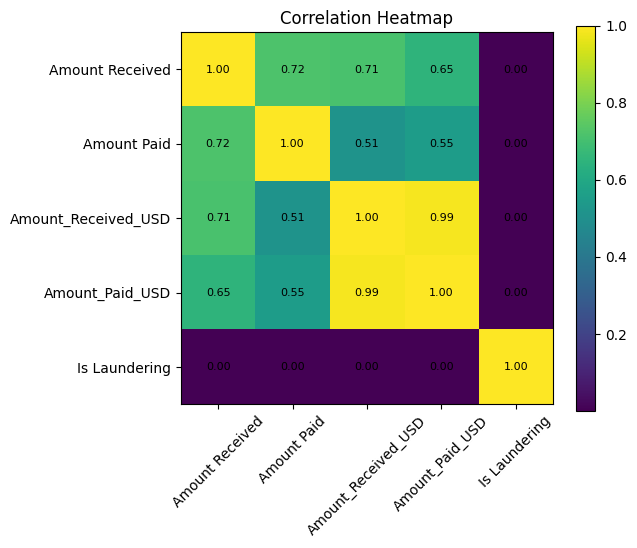

In [ ]:
# 6. 상관관계 히트맵

num_df = (
    df.select([
        "Amount Received",
        "Amount Paid",
        "Amount_Received_USD",
        "Amount_Paid_USD",
        "Is Laundering"
    ])
    .collect()
    .to_pandas()
)

corr = num_df.corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)

plt.title("Correlation Heatmap")

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j, i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.show()



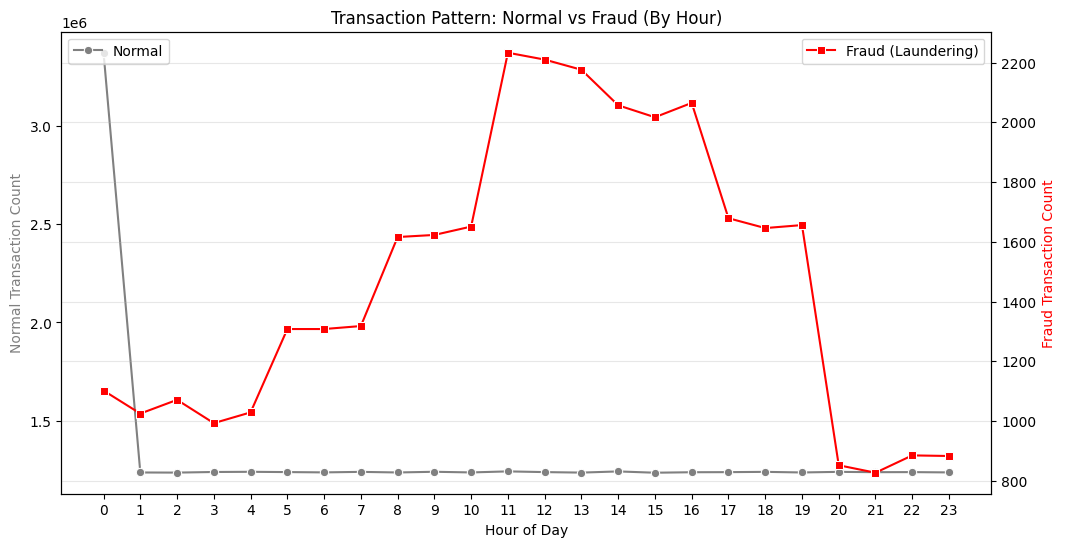

In [ ]:
# 7-1 시간별 거래 패턴

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 집계 (Lazy)
# 정상과 사기를 구분하여 시간대별 카운트 계산
time_dist = (
    df.with_columns([
        pl.col("Timestamp").dt.hour().alias("Hour"),
        pl.when(pl.col("Is Laundering") == 1).then(pl.lit("Fraud")).otherwise(pl.lit("Normal")).alias("Type")
    ])
    .group_by(["Hour", "Type"])
    .len(name="Count")
    .collect()
    .to_pandas()
)

# 2. 시각화 (Dual Axes 또는 Subplots)
# 정상 거래와 사기 거래의 규모 차이가 크기 때문에, 비중(Density)으로 보거나 축을 분리하는 게 좋습니다.
fig, ax1 = plt.subplots(figsize=(12, 6))

# 정상 거래 그래프 (왼쪽 축)
sns.lineplot(data=time_dist[time_dist["Type"] == "Normal"],
             x="Hour", y="Count", ax=ax1, color='gray', label='Normal', marker='o')
ax1.set_ylabel('Normal Transaction Count', color='gray')
ax1.set_xlabel('Hour of Day')

# 사기 거래 그래프 (오른쪽 축 공유)
ax2 = ax1.twinx()
sns.lineplot(data=time_dist[time_dist["Type"] == "Fraud"],
             x="Hour", y="Count", ax=ax2, color='red', label='Fraud (Laundering)', marker='s')
ax2.set_ylabel('Fraud Transaction Count', color='red')

plt.title("Transaction Pattern: Normal vs Fraud (By Hour)")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipython-input-1255977863.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_dist[day_dist["Type"] == "Normal"],
/tmp/ipython-input-1255977863.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_dist[day_dist["Type"] == "Fraud"],


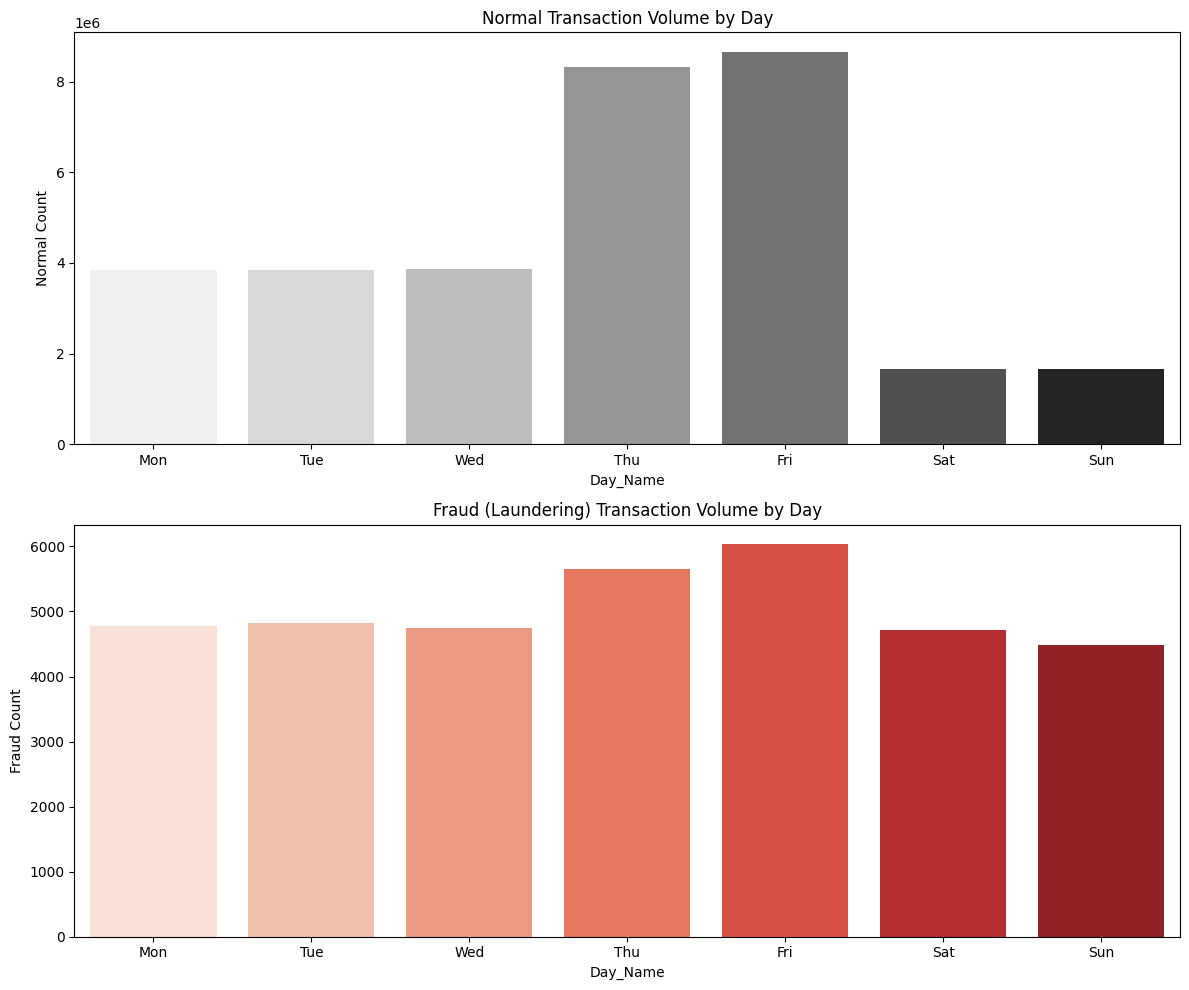


[요일별 사기 거래 비중]
Type      Fraud_Rate (%)
Day_Name                
Mon             0.123674
Tue             0.124966
Wed             0.122948
Thu             0.067812
Fri             0.069595
Sat             0.283707
Sun             0.270080


In [ ]:
# 7-2 요일별 거래 패턴
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 요일별 데이터 집계 (Lazy)
day_dist = (
    df.with_columns([
        pl.col("Timestamp").dt.weekday().alias("Day_of_Week"), # 1(월) ~ 7(일)
        pl.when(pl.col("Is Laundering") == 1).then(pl.lit("Fraud")).otherwise(pl.lit("Normal")).alias("Type")
    ])
    .group_by(["Day_of_Week", "Type"])
    .len(name="Count")
    .collect()
    .to_pandas()
)

# 요일 이름 매핑
day_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
day_dist["Day_Name"] = day_dist["Day_of_Week"].map(day_map)

# 2. 시각화 (정상과 사기의 규모 차이를 고려해 개별 서브플롯 생성)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# [정상 거래 요일별 분포]
sns.barplot(data=day_dist[day_dist["Type"] == "Normal"],
            x="Day_Name", y="Count", order=day_order, ax=ax1, palette="Greys")
ax1.set_title("Normal Transaction Volume by Day")
ax1.set_ylabel("Normal Count")

# [사기 거래 요일별 분포]
sns.barplot(data=day_dist[day_dist["Type"] == "Fraud"],
            x="Day_Name", y="Count", order=day_order, ax=ax2, palette="Reds")
ax2.set_title("Fraud (Laundering) Transaction Volume by Day")
ax2.set_ylabel("Fraud Count")

plt.tight_layout()
plt.show()

# 3. 추가 분석: 요일별 사기 거래 비중 (%)
fraud_ratio = day_dist.pivot(index="Day_Name", columns="Type", values="Count").fillna(0)
fraud_ratio["Fraud_Rate (%)"] = (fraud_ratio["Fraud"] / (fraud_ratio["Normal"] + fraud_ratio["Fraud"])) * 100
print("\n[요일별 사기 거래 비중]")
print(fraud_ratio.reindex(day_order)[["Fraud_Rate (%)"]])

/tmp/ipython-input-2216743655.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


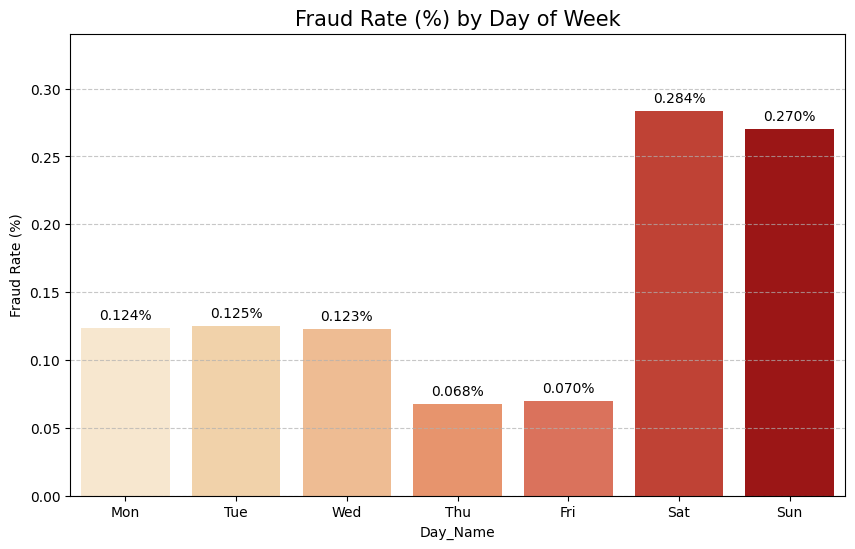

In [ ]:
#7-3 요일별 사기거래 비율
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 요일별 사기율 계산 (Lazy)
fraud_rate_df = (
    df.with_columns(
        pl.col("Timestamp").dt.weekday().alias("Day_of_Week")
    )
    .group_by("Day_of_Week")
    .agg([
        pl.len().alias("Total_Count"),
        pl.col("Is Laundering").sum().alias("Fraud_Count")
    ])
    .with_columns(
        (pl.col("Fraud_Count") / pl.col("Total_Count") * 100).alias("Fraud_Rate_Pct")
    )
    .sort("Day_of_Week")
    .collect()
    .to_pandas()
)

# 요일 이름 매핑
day_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
fraud_rate_df["Day_Name"] = fraud_rate_df["Day_of_Week"].map(day_map)

# 2. 시각화
plt.figure(figsize=(10, 6))
day_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

ax = sns.barplot(
    data=fraud_rate_df,
    x="Day_Name",
    y="Fraud_Rate_Pct",
    order=day_order,
    palette="OrRd"
)

# 바 위에 퍼센트 수치 표시
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.title("Fraud Rate (%) by Day of Week", fontsize=15)
plt.ylabel("Fraud Rate (%)")
plt.ylim(0, fraud_rate_df["Fraud_Rate_Pct"].max() * 1.2) # 상단 여유 공간
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

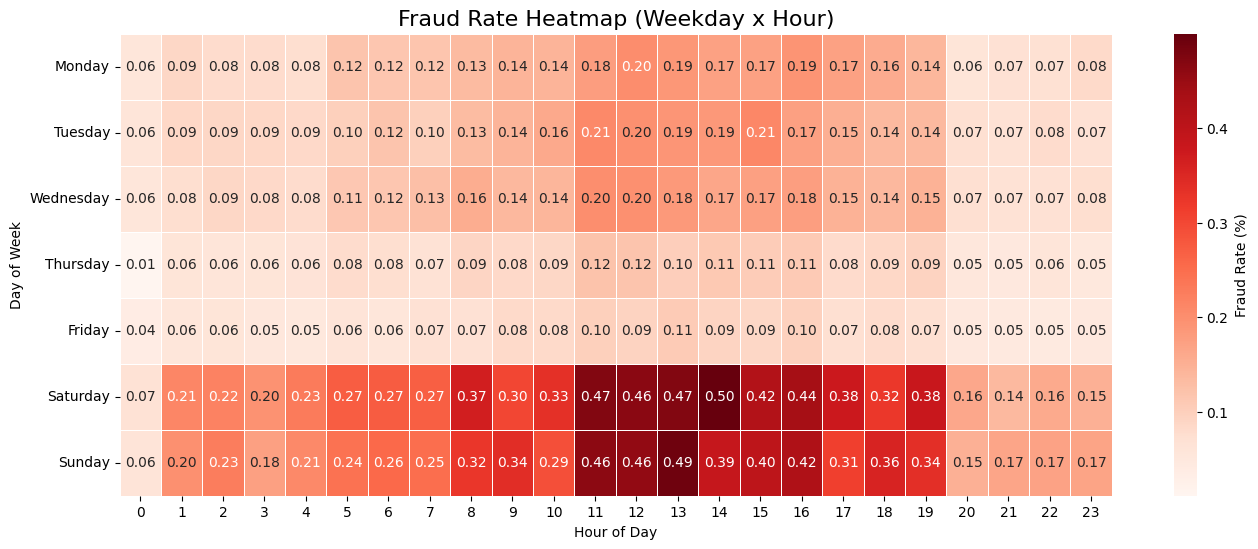

In [ ]:
#7-4. 요일 x 시간별 사기율 히트맵

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 요일 & 시간별 사기율 데이터 생성 (Lazy)
heatmap_data = (
    df.with_columns([
        pl.col("Timestamp").dt.hour().alias("Hour"),
        pl.col("Timestamp").dt.weekday().alias("Day_of_Week")
    ])
    .group_by(["Day_of_Week", "Hour"])
    .agg([
        pl.len().alias("Total"),
        pl.col("Is Laundering").sum().alias("Fraud")
    ])
    .with_columns(
        (pl.col("Fraud") / pl.col("Total") * 100).alias("Fraud_Rate")
    )
    .collect()
    .to_pandas()
)

# 2. 히트맵을 그리기 위한 피벗 테이블 생성
# index: 요일, columns: 시간, values: 사기율
pivot_df = heatmap_data.pivot(index="Day_of_Week", columns="Hour", values="Fraud_Rate")

# 요일 이름 매핑 (1~7 -> Mon~Sun)
day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_df.index = day_names

# 3. 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    pivot_df,
    annot=True,          # 수치 표시 (데이터가 너무 많으면 False로 변경)
    fmt=".2f",           # 소수점 둘째 자리까지
    cmap="Reds",         # 사기니까 빨간색 계열
    linewidths=.5,       # 격자선
    cbar_kws={'label': 'Fraud Rate (%)'}
)

plt.title("Fraud Rate Heatmap (Weekday x Hour)", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

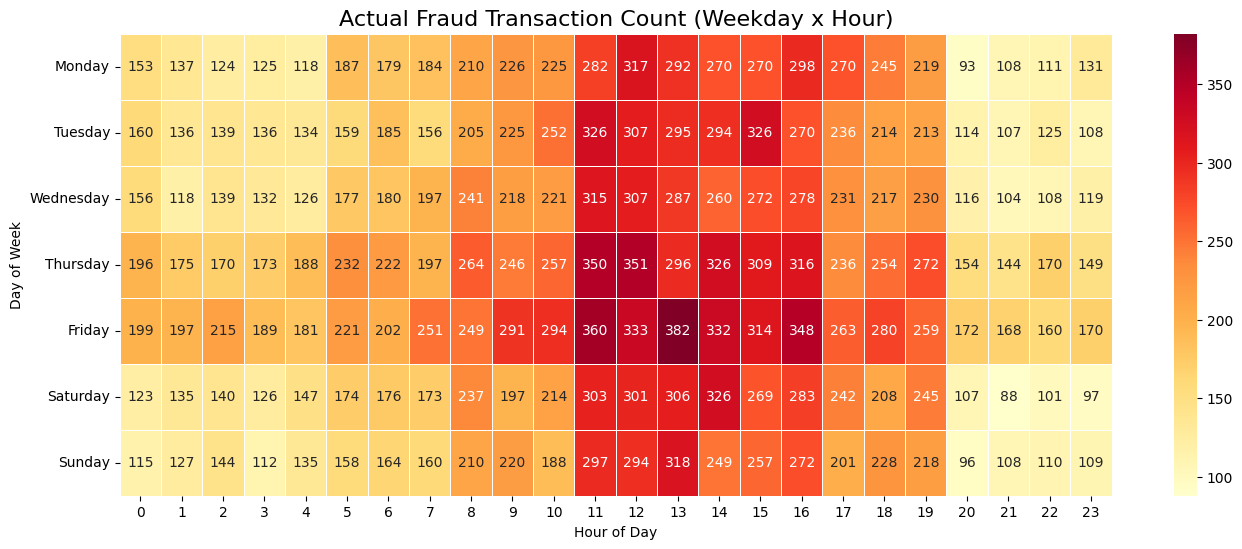

In [ ]:
#7-4. 요일 x 시간별 사기건수 히트맵

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 요일 & 시간별 사기 건수 집계 (Lazy)
heatmap_count = (
    df.filter(pl.col("Is Laundering") == 1) # 사기 거래만 필터링
    .with_columns([
        pl.col("Timestamp").dt.hour().alias("Hour"),
        pl.col("Timestamp").dt.weekday().alias("Day_of_Week")
    ])
    .group_by(["Day_of_Week", "Hour"])
    .len(name="Fraud_Count") # 건수 집계
    .collect()
    .to_pandas()
)

# 2. 피벗 테이블 (건수 기준)
pivot_count = heatmap_count.pivot(index="Day_of_Week", columns="Hour", values="Fraud_Count").fillna(0)

# 요일 이름 매핑
day_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot_count.index = day_names

# 3. 시각화
plt.figure(figsize=(16, 6))
sns.heatmap(
    pivot_count,
    annot=True,
    fmt=".0f",        # 건수니까 정수로 표시
    cmap="YlOrRd",    # 노랑 -> 주황 -> 빨강 (빈도 시각화에 적합)
    linewidths=.5
)

plt.title("Actual Fraud Transaction Count (Weekday x Hour)", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

/tmp/ipython-input-307404303.py:25: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  in_degree.join(out_degree, on="Account", how="outer")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


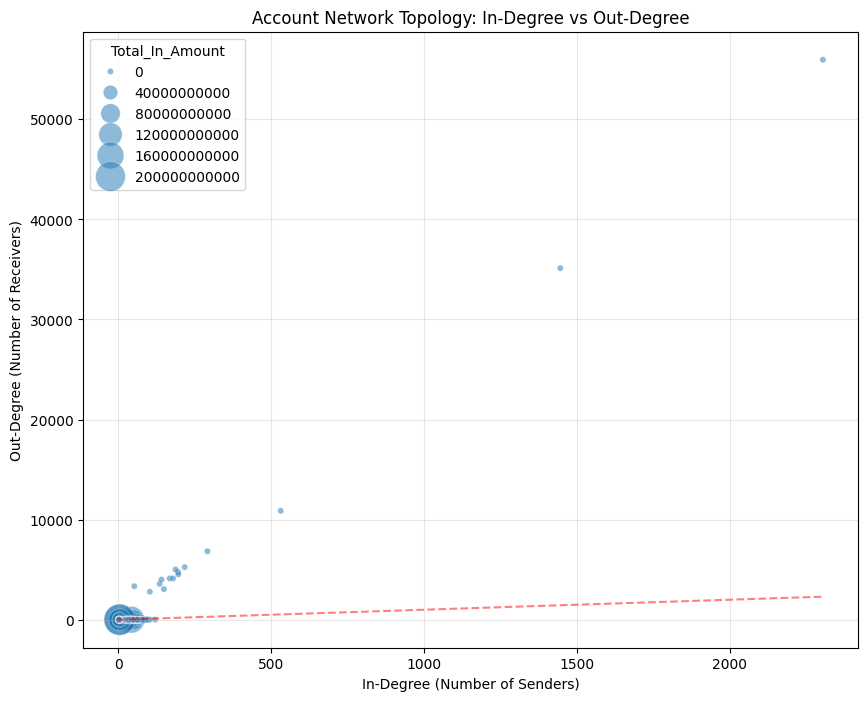

In [ ]:
#8. 네트워크 Topology (In-Degree vs Out-Degree 로그를 안취함

# 1. In-Degree 계산 (받는 계좌 기준)
in_degree = (
    df.group_by("To Account")
    .agg([
        pl.col("From Account").n_unique().alias("In_Degree"),
        pl.col("Amount_Received_USD").sum().alias("Total_In_Amount")
    ])
    .rename({"To Account": "Account"})
)

# 2. Out-Degree 계산 (보내는 계좌 기준)
out_degree = (
    df.group_by("From Account")
    .agg([
        pl.col("To Account").n_unique().alias("Out_Degree"),
        pl.col("Amount_Paid_USD").sum().alias("Total_Out_Amount")
    ])
    .rename({"From Account": "Account"})
)

# 3. 데이터 결합 (Outer Join)
topology = (
    in_degree.join(out_degree, on="Account", how="outer")
    .fill_null(0) # 거래가 없는 쪽은 0으로 채움
    .with_columns([
        # 사기 여부 확인을 위해 원본에서 계좌별 Is Laundering 여부 매핑 (Optional)
        # 여기서는 간단히 두 수치의 상관관계를 시각화하는 데 집중합니다.
    ])
    .collect()
    .to_pandas()
)

# 4. 시각화 (In-Degree vs Out-Degree 산점도)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=topology,
    x="In_Degree",
    y="Out_Degree",
    alpha=0.5,
    size="Total_In_Amount", # 거래 규모를 점 크기로 표현
    sizes=(20, 500)
)

# 대각선 (In=Out 대칭선)
plt.plot([0, topology["In_Degree"].max()], [0, topology["In_Degree"].max()], 'r--', alpha=0.5)

plt.title("Account Network Topology: In-Degree vs Out-Degree")
plt.xlabel("In-Degree (Number of Senders)")
plt.ylabel("Out-Degree (Number of Receivers)")
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


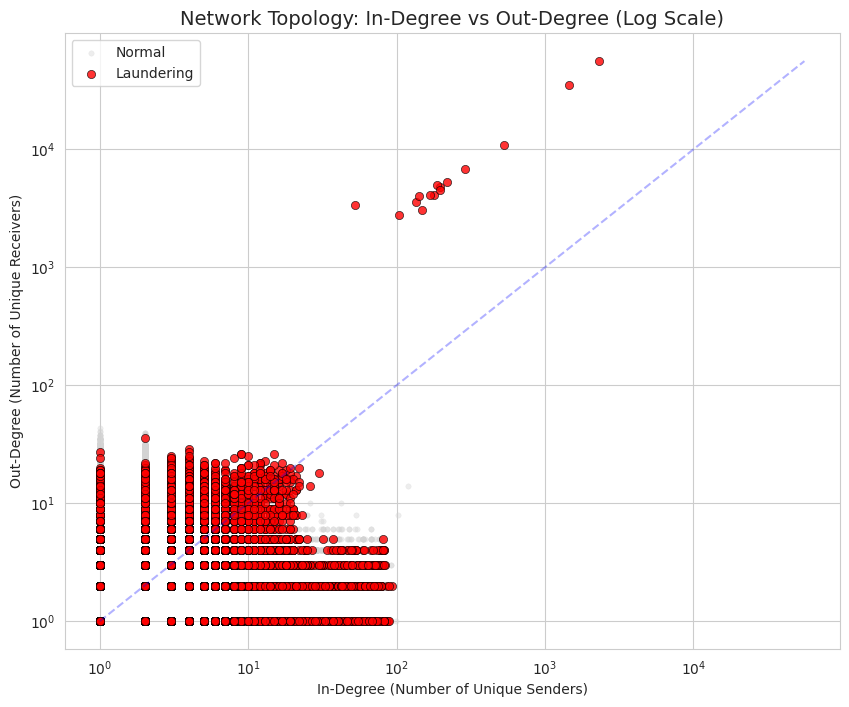

In [ ]:
# 8. 네트워크 Topology (In-Degree vs Out-Degree)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 사기 거래에 연루된 모든 계좌 리스트 추출 (보낸 놈 + 받은 놈)
# Lazy 상태를 유지하며 집합을 만듭니다.
fraud_from = df.filter(pl.col("Is Laundering") == 1).select(pl.col("From Account").alias("Account"))
fraud_to = df.filter(pl.col("Is Laundering") == 1).select(pl.col("To Account").alias("Account"))
fraud_accounts = pl.concat([fraud_from, fraud_to]).unique()

# 2. In/Out Degree 집계
# In-Degree: 수취 계좌 기준 송금자 수
in_degree = df.group_by("To Account").agg(
    pl.col("From Account").n_unique().alias("In_Degree")
).rename({"To Account": "Account"})

# Out-Degree: 송금 계좌 기준 수취자 수
out_degree = df.group_by("From Account").agg(
    pl.col("To Account").n_unique().alias("Out_Degree")
).rename({"From Account": "Account"})

# 3. 데이터 통합 (Full Join & Fraud Tagging)
topology = (
    in_degree.join(out_degree, on="Account", how="full") # outer -> full 로 수정
    .fill_null(0)
    # 사기 계좌 리스트와 Join하여 여부 확인
    .join(fraud_accounts.with_columns(pl.lit(True).alias("Is_Fraud")), on="Account", how="left")
    .with_columns(
        pl.col("Is_Fraud").fill_null(False)
    )
    .with_columns(
        pl.when(pl.col("Is_Fraud")).then(pl.lit("Laundering")).otherwise(pl.lit("Normal")).alias("Label")
    )
    .collect()
    .to_pandas()
)

# 4. 시각화 (Log-Log Plot)
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# 정상 데이터 (회색)
sns.scatterplot(
    data=topology[topology["Label"] == "Normal"],
    x="In_Degree", y="Out_Degree",
    color="lightgray", alpha=0.4, s=15, label="Normal",
    edgecolor=None
)

# 사기 데이터 (빨간색) - 정상 데이터 위에 덮어씌움
sns.scatterplot(
    data=topology[topology["Label"] == "Laundering"],
    x="In_Degree", y="Out_Degree",
    color="red", alpha=0.8, s=35, label="Laundering",
    edgecolor="black", linewidth=0.5
)

# 로그 스케일 적용 (0이 있으면 로그를 못 취하므로 1로 보정하거나, symlog 사용 가능)
# 여기서는 0차수인 경우 시각화를 위해 최소값 0.1 등으로 처리되게 plt가 알아서 조정합니다.
plt.xscale('log')
plt.yscale('log')

# 가이드 라인 (In=Out)
max_val = max(topology["In_Degree"].max(), topology["Out_Degree"].max())
plt.plot([1, max_val], [1, max_val], color='blue', linestyle='--', alpha=0.3)

plt.title("Network Topology: In-Degree vs Out-Degree (Log Scale)", fontsize=14)
plt.xlabel("In-Degree (Number of Unique Senders)")
plt.ylabel("Out-Degree (Number of Unique Receivers)")
plt.legend()
plt.show()

/tmp/ipython-input-2785365016.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


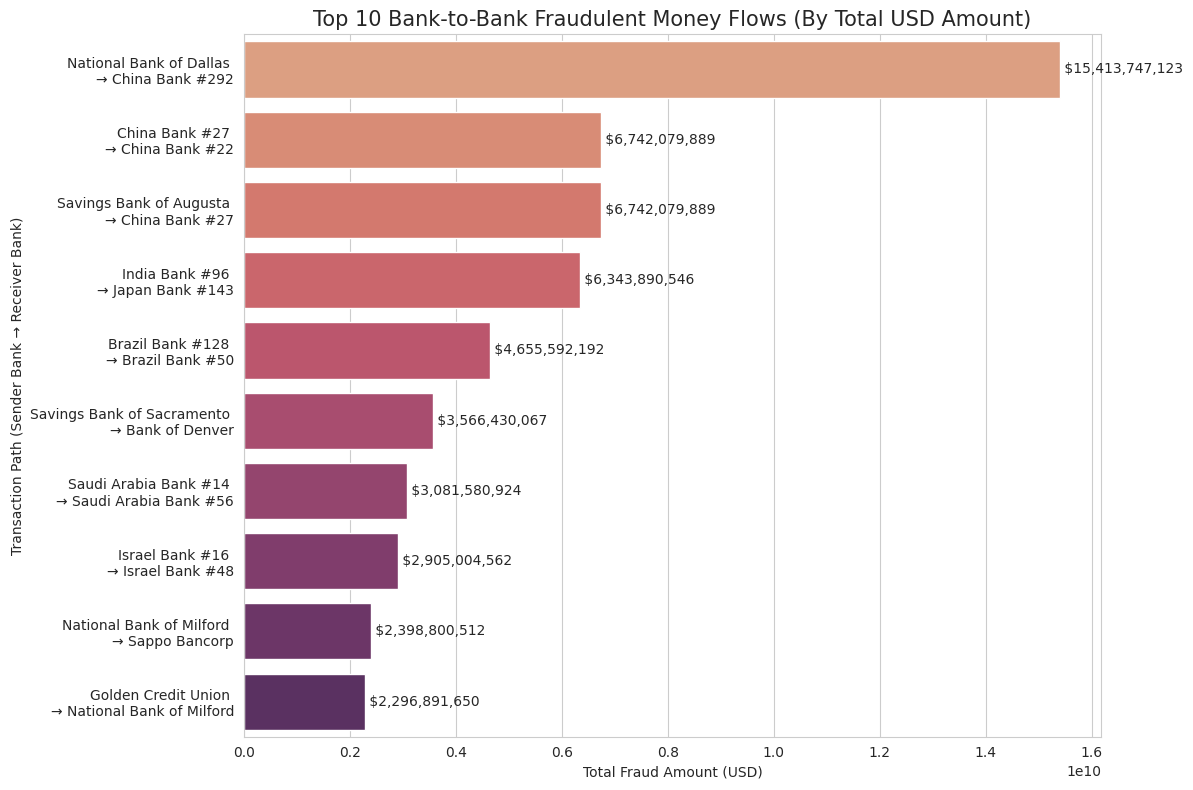

In [ ]:
# 9. 은행 간 사기 거래 자금 흐름 (Top 10)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 은행 간 사기 자금 흐름 집계 (Lazy)
bank_fraud_flow = (
    df.filter(pl.col("Is Laundering") == 1)
    .group_by(["Sender_Bank_Name", "Receiver_Bank_Name"])
    .agg([
        pl.len().alias("Fraud_Transaction_Count"),
        pl.col("Amount_Paid_USD").sum().alias("Total_Fraud_Amount_USD")
    ])
    .sort("Total_Fraud_Amount_USD", descending=True)
    .head(10) # 상위 10개 경로 추출
    .collect()
    .to_pandas()
)

# 2. 시각화용 경로 라벨 생성
bank_fraud_flow["Flow_Path"] = (
    bank_fraud_flow["Sender_Bank_Name"] + " \n→ " + bank_fraud_flow["Receiver_Bank_Name"]
)

# 3. 시각화 (막대 그래프)
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.barplot(
    data=bank_fraud_flow,
    x="Total_Fraud_Amount_USD",
    y="Flow_Path",
    palette="flare"
)

plt.title("Top 10 Bank-to-Bank Fraudulent Money Flows (By Total USD Amount)", fontsize=15)
plt.xlabel("Total Fraud Amount (USD)")
plt.ylabel("Transaction Path (Sender Bank → Receiver Bank)")

# 금액 수치 표시
for i, v in enumerate(bank_fraud_flow["Total_Fraud_Amount_USD"]):
    plt.text(v, i, f' ${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

계산된 데이터 건수: 29885042


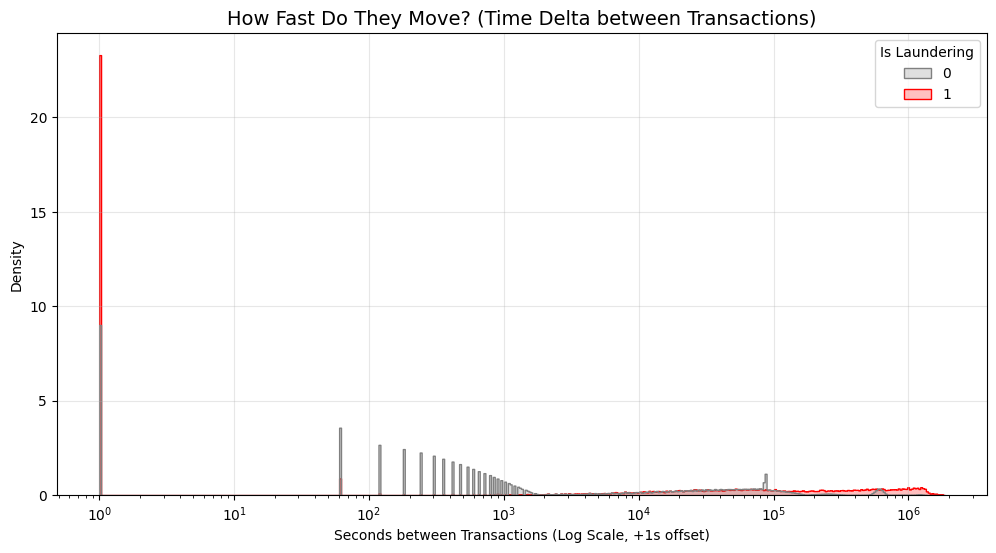

In [ ]:
# 10. 거래 속도 (Time Delta)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 각 계좌(From Account)별로 거래 사이의 시간차 계산
delta_df = (
    df.sort(["From Account", "Timestamp"])
    .with_columns([
        # 동일한 발신 계좌 내에서 현재 거래 시간 - 직전 거래 시간
        (pl.col("Timestamp") - pl.col("Timestamp").shift(1).over("From Account"))
        .dt.total_seconds()
        .alias("Time_Delta_Sec")
    ])
    # 시간차가 0보다 크고 (동시 거래 제외 혹은 포함 선택), Null이 아닌 것들만
    .filter(pl.col("Time_Delta_Sec").is_not_null())
    .collect()
)

# Sanity Check: 데이터가 실제로 있는지 확인
print(f"계산된 데이터 건수: {len(delta_df)}")

# 2. 시각화 (데이터가 있을 때만 실행)
if len(delta_df) > 0:
    plt.figure(figsize=(12, 6))

    # 0초나 너무 작은 값 때문에 로그 스케일에서 에러날 수 있으니 +1초 보정
    plot_data = delta_df.to_pandas()
    plot_data['Time_Delta_Log'] = plot_data['Time_Delta_Sec'] + 1

    sns.histplot(
        data=plot_data,
        x="Time_Delta_Log",
        hue="Is Laundering",
        element="step",
        stat="density",
        common_norm=False,
        log_scale=True,
        palette={0: "gray", 1: "red"}
    )

    plt.title("How Fast Do They Move? (Time Delta between Transactions)", fontsize=14)
    plt.xlabel("Seconds between Transactions (Log Scale, +1s offset)")
    plt.ylabel("Density")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("데이터가 부족하여 그래프를 그릴 수 없습니다. 계좌별 거래 건수를 확인해보세요!")

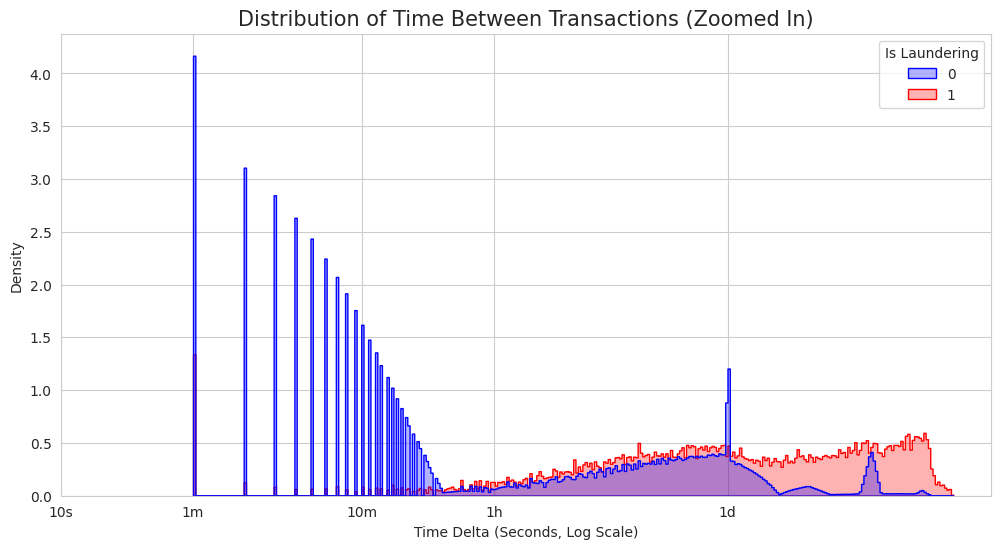

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 10초 이상 거래만 필터링 (X축 확대를 위해)
# 만약 1초 근처도 보고 싶다면 filter 조건을 빼거나 낮춰주세요.
zoom_delta = delta_df.filter(pl.col("Time_Delta_Sec") >= 10).to_pandas()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 2. 두 데이터의 분포를 겹쳐서 그리기
sns.histplot(
    data=zoom_delta,
    x="Time_Delta_Sec",
    hue="Is Laundering",
    element="step",       # 경계선이 있는 계단형 히스토그램
    fill=True,            # 안쪽 채우기
    alpha=0.3,            # 투명도 조절로 겹치는 부위 보라색 연출
    stat="density",       # 비율로 표시 (정상/사기 건수 차이가 커도 비교 가능)
    common_norm=False,    # 각 그룹별로 합계가 1이 되도록 정규화
    log_scale=True,       # 넓은 시간 범위를 보기 위해 로그 스케일 유지
    palette={0: "blue", 1: "red"} # 파랑 + 빨강 = 겹치는 곳 보라색
)

plt.title("Distribution of Time Between Transactions (Zoomed In)", fontsize=15)
plt.xlabel("Time Delta (Seconds, Log Scale)")
plt.ylabel("Density")

# 가독성을 위한 눈금 설정 (10초, 1분, 1시간 등)
plt.xticks([10, 60, 600, 3600, 86400], ['10s', '1m', '10m', '1h', '1d'])

plt.show()

In [ ]:
# 1. 1초 이하 거래 비중 계산
speed_analysis = (
    delta_df # 이미 collect된 상태라면 아래처럼, Lazy 상태라면 그대로 진행
    .with_columns(
        pl.when(pl.col("Time_Delta_Sec") <= 1)
        .then(pl.lit("Ultra-Fast (<=1s)"))
        .otherwise(pl.lit("Regular (>1s)"))
        .alias("Speed_Category")
    )
    .group_by(["Is Laundering", "Speed_Category"]) # 원본 컬럼명인 'Is Laundering' 사용
    .agg(pl.len().alias("Count"))
)

# 2. 결과 출력 및 비율 계산
res = speed_analysis.collect() if isinstance(speed_analysis, pl.LazyFrame) else speed_analysis

# 결과를 보기 좋게 피벗
summary_df = (
    res.to_pandas()
    .pivot(index="Is Laundering", columns="Speed_Category", values="Count")
    .fillna(0)
)

# 비율 계산
summary_df["Total"] = summary_df["Regular (>1s)"] + summary_df["Ultra-Fast (<=1s)"]
summary_df["Ultra-Fast_Rate(%)"] = (summary_df["Ultra-Fast (<=1s)"] / summary_df["Total"]) * 100

print("--- [사기 거래 vs 정상 거래: 초고속 거래 비중 비교] ---")
print(summary_df)

# 💡 더 직관적인 비교를 위한 출력
for is_fraud in [0, 1]:
    label = "사기 거래(Laundering)" if is_fraud == 1 else "정상 거래(Normal)"
    rate = summary_df.loc[is_fraud, "Ultra-Fast_Rate(%)"]
    print(f"[{label}] 1초 이내 재송금 비율: {rate:.2f}%")

--- [사기 거래 vs 정상 거래: 초고속 거래 비중 비교] ---
Speed_Category  Regular (>1s)  Ultra-Fast (<=1s)     Total  Ultra-Fast_Rate(%)
Is Laundering                                                                 
0                    26113752            3737189  29850941           12.519501
1                       23059              11042     34101           32.380282
[정상 거래(Normal)] 1초 이내 재송금 비율: 12.52%
[사기 거래(Laundering)] 1초 이내 재송금 비율: 32.38%


In [ ]:
import polars as pl

# 1. 아까 형님이 정해주신 '0초 거래' 데이터만 딱 떼어냅니다.
# (정상 3,737,189건 / 사기 11,042건이 들어있는 그 데이터프레임입니다.)
zero_trades_only = delta_df.filter(pl.col("Time_Delta_Sec") == 0)

# 2. 이 '0초 거래' 안에서만 계좌별로 거래 순서를 매깁니다.
# 전체 거래 내역이 아니라, "자동이체 중 몇 번째인가"를 보는 겁니다.
zero_analysis = zero_trades_only.sort(["From Account", "Timestamp"]).with_columns([
    pl.col("Timestamp").rank("dense").over("From Account").alias("Zero_Trade_Order")
])

# 3. 1회성(첫 자동이체) vs 2회 이상 상습 자동이체 분류
final_fix = (
    zero_analysis.with_columns([
        pl.when(pl.col("Zero_Trade_Order") == 1)
        .then(pl.lit("First_Trade (1회)"))
        .otherwise(pl.lit("Repeat_Trade (2회 이상)"))
        .alias("Frequency_Type")
    ])
    .group_by(["Is Laundering", "Frequency_Type"])
    .agg(pl.len().alias("Count"))
    .with_columns([
        # 정상/사기 각각의 합계로 나눠서 비율(%) 계산
        (pl.col("Count") / pl.col("Count").sum().over("Is Laundering") * 100).round(2).alias("Percentage(%)"),
        pl.when(pl.col("Is Laundering") == 0).then(pl.lit("Normal (정상)")).otherwise(pl.lit("Fraud (사기)")).alias("Status")
    ])
    .sort(["Status", "Frequency_Type"])
)

# 4. 결과 출력
print("--- [0초 자동이체 범위 한정: 첫 거래 vs 다회 거래 분석] ---")
print(final_fix.select(["Status", "Frequency_Type", "Count", "Percentage(%)"]))

--- [0초 자동이체 범위 한정: 첫 거래 vs 다회 거래 분석] ---
shape: (4, 4)
┌───────────────┬─────────────────────────┬─────────┬───────────────┐
│ Status        ┆ Frequency_Type          ┆ Count   ┆ Percentage(%) │
│ ---           ┆ ---                     ┆ ---     ┆ ---           │
│ str           ┆ str                     ┆ u32     ┆ f64           │
╞═══════════════╪═════════════════════════╪═════════╪═══════════════╡
│ Fraud (사기)  ┆ First_Trade (1회)       ┆ 4171    ┆ 37.77         │
│ Fraud (사기)  ┆ Repeat_Trade (2회 이상) ┆ 6871    ┆ 62.23         │
│ Normal (정상) ┆ First_Trade (1회)       ┆ 293073  ┆ 7.84          │
│ Normal (정상) ┆ Repeat_Trade (2회 이상) ┆ 3444116 ┆ 92.16         │
└───────────────┴─────────────────────────┴─────────┴───────────────┘


In [ ]:
import polars as pl

# 1. '0초'이면서 동시에 '사기(1)'인 거래만 칼같이 필터링
# delta_df가 DataFrame인 경우를 가정합니다. (AttributeError 방지)
pure_fraud_zero_df = delta_df.filter(
    (pl.col("Time_Delta_Sec") == 0) & (pl.col("Is Laundering") == 1)
)

# 2. 사기꾼들의 송금 방향성 분석
direction_analysis = (
    pure_fraud_zero_df.group_by("From Account")
    .agg([
        pl.col("To Account").n_unique().alias("Destination_Count"),
        pl.col("Amount_Paid_USD").sum().alias("Total_Amount"),
        pl.len().alias("Transaction_Count")
    ])
    .with_columns([
        pl.when(pl.col("Destination_Count") == 1)
          .then(pl.lit("Single-Target (Collection)"))
          .otherwise(pl.lit("Multi-Target (Scattering)"))
          .alias("Transfer_Pattern")
    ])
    .sort("Destination_Count", descending=True)
)

# 3. 결과 요약 출력
print(f"--- [수사 보고: 0초 & 사기 거래 패턴 요약] ---")
print(f"분석 대상 사기 거래 건수: {len(pure_fraud_zero_df)} 건")
summary = direction_analysis.group_by("Transfer_Pattern").agg(pl.len().alias("Account_Count"))
print(summary)

# 4. 사기 자금을 사방으로 쪼개 보내는 '세탁기' TOP 10
print("\n--- [사기 자금 살포형 계좌 TOP 10] ---")
print(direction_analysis.filter(pl.col("Destination_Count") > 1).head(10))

# 5. 사기 자금을 한곳으로 모으는 '수거책' TOP 10
print("\n--- [사기 자금 수거형 계좌 TOP 10] ---")
print(direction_analysis.filter(pl.col("Destination_Count") == 1).sort("Total_Amount", descending=True).head(10))

--- [수사 보고: 0초 & 사기 거래 패턴 요약] ---
분석 대상 사기 거래 건수: 11042 건
shape: (2, 2)
┌────────────────────────────┬───────────────┐
│ Transfer_Pattern           ┆ Account_Count │
│ ---                        ┆ ---           │
│ str                        ┆ u32           │
╞════════════════════════════╪═══════════════╡
│ Single-Target (Collection) ┆ 5358          │
│ Multi-Target (Scattering)  ┆ 493           │
└────────────────────────────┴───────────────┘

--- [사기 자금 살포형 계좌 TOP 10] ---
shape: (10, 5)
┌──────────────┬───────────────────┬──────────────┬───────────────────┬───────────────────────────┐
│ From Account ┆ Destination_Count ┆ Total_Amount ┆ Transaction_Count ┆ Transfer_Pattern          │
│ ---          ┆ ---               ┆ ---          ┆ ---               ┆ ---                       │
│ str          ┆ u32               ┆ f64          ┆ u32               ┆ str                       │
╞══════════════╪═══════════════════╪══════════════╪═══════════════════╪═══════════════════════════╡
│ 1004

In [ ]:


import polars as pl

# 1. '0초'이면서 '사기(1)'인 거래만 필터링
pure_fraud_zero_df = delta_df.filter(
    (pl.col("Time_Delta_Sec") == 0) & (pl.col("Is Laundering") == 1)
)

# 2. 계좌별 기본 분석 (방향성 및 해당 계좌의 거래 건수 합산)
direction_analysis = (
    pure_fraud_zero_df.group_by("From Account")
    .agg([
        pl.col("To Account").n_unique().alias("Destination_Count"),
        pl.col("Amount_Paid_USD").sum().alias("Total_Amount"),
        pl.len().alias("Individual_Transaction_Count") # 각 계좌가 일으킨 거래 수
    ])
    .with_columns([
        pl.when(pl.col("Destination_Count") == 1)
          .then(pl.lit("Single-Target (Collection)"))
          .otherwise(pl.lit("Multi-Target (Scattering)"))
          .alias("Transfer_Pattern")
    ])
)

# 3. 패턴별 요약 (계좌 수 + 사기 거래 건수 합계)
summary = (
    direction_analysis.group_by("Transfer_Pattern")
    .agg([
        pl.len().alias("Account_Count"), # 계좌가 몇 개인가?
        pl.col("Individual_Transaction_Count").sum().alias("Total_Fraud_Transactions") # 거래를 총 몇 번 했나?
    ])
    .sort("Account_Count", descending=True)
)

# 4. 결과 출력
print(f"--- [수사 보고: 0초 & 사기 거래 패턴 요약] ---")
print(f"전체 사기 거래 분석 대상: {len(pure_fraud_zero_df)} 건")
print(summary)

# 5. 상위 리스트는 그대로 유지
print("\n--- [사기 자금 살포형(Scattering) TOP 5] ---")
print(direction_analysis.filter(pl.col("Transfer_Pattern") == "Multi-Target (Scattering)").sort("Destination_Count", descending=True).head(5))

--- [수사 보고: 0초 & 사기 거래 패턴 요약] ---
전체 사기 거래 분석 대상: 11042 건
shape: (2, 3)
┌────────────────────────────┬───────────────┬──────────────────────────┐
│ Transfer_Pattern           ┆ Account_Count ┆ Total_Fraud_Transactions │
│ ---                        ┆ ---           ┆ ---                      │
│ str                        ┆ u32           ┆ u32                      │
╞════════════════════════════╪═══════════════╪══════════════════════════╡
│ Single-Target (Collection) ┆ 5358          ┆ 5370                     │
│ Multi-Target (Scattering)  ┆ 493           ┆ 5672                     │
└────────────────────────────┴───────────────┴──────────────────────────┘

--- [사기 자금 살포형(Scattering) TOP 5] ---
shape: (5, 5)
┌──────────────┬───────────────────┬──────────────┬─────────────────────────────┬──────────────────┐
│ From Account ┆ Destination_Count ┆ Total_Amount ┆ Individual_Transaction_Coun ┆ Transfer_Pattern │
│ ---          ┆ ---               ┆ ---          ┆ t                           ┆

In [ ]:
import polars as pl

# 0. 출력 제한 해제 (모든 행과 모든 열을 다 보여주도록 설정)
with pl.Config(tbl_rows=-1, tbl_cols=-1):

    # 1. 0초 & 사기 거래 필터링
    pure_fraud_zero_df = delta_df.filter(
        (pl.col("Time_Delta_Sec") == 0) & (pl.col("Is Laundering") == 1)
    )

    # 2. 받은 계좌(To Account)별 집계
    collection_analysis = (
        pure_fraud_zero_df.group_by("To Account")
        .agg([
            pl.col("From Account").n_unique().alias("Sender_Count"),
            pl.col("Amount_Paid_USD").sum().alias("Total_Received"),
            pl.len().alias("Transaction_Count")
        ])
        .sort("Sender_Count", descending=True)
    )

    # 3. 요약 통계: 송금자 수별 수거 계좌 분포
    dist_summary = (
        collection_analysis.group_by("Sender_Count")
        .agg(pl.len().alias("Receiver_Account_Count"))
        .sort("Sender_Count", descending=True)
    )

    print("--- [수사 보고: 송금자 수별 수거 계좌 분포 (전체)] ---")
    print(dist_summary)

--- [수사 보고: 송금자 수별 수거 계좌 분포 (전체)] ---
shape: (11, 2)
┌──────────────┬────────────────────────┐
│ Sender_Count ┆ Receiver_Account_Count │
│ ---          ┆ ---                    │
│ u32          ┆ u32                    │
╞══════════════╪════════════════════════╡
│ 12           ┆ 1                      │
│ 10           ┆ 3                      │
│ 9            ┆ 5                      │
│ 8            ┆ 17                     │
│ 7            ┆ 26                     │
│ 6            ┆ 37                     │
│ 5            ┆ 79                     │
│ 4            ┆ 87                     │
│ 3            ┆ 102                    │
│ 2            ┆ 176                    │
│ 1            ┆ 8918                   │
└──────────────┴────────────────────────┘


In [ ]:
import polars as pl

# 1. 먼저 전체 데이터(df)에서 계좌별 거래 순서(Order)를 매깁니다.
# (이게 있어야 이 거래가 생애 첫 거래인지 알 수 있습니다.)
df_ordered = df.sort(["From Account", "Timestamp"]).with_columns([
    pl.col("Timestamp").rank("dense").over("From Account").alias("Transaction_Order")
]).collect()

# 2. 형님이 말씀하신 '0초 거래'만 필터링 (delta_df 활용)
# delta_df에는 이미 Time_Delta_Sec과 Is Laundering이 계산되어 있습니다.
zero_trades = delta_df.filter(pl.col("Time_Delta_Sec") == 0)

# 3. 0초 거래에 '거래 순서' 정보 결합
zero_analysis = zero_trades.join(
    df_ordered.select(["From Account", "Timestamp", "Transaction_Order"]),
    on=["From Account", "Timestamp"],
    how="inner"
)

# 4. 첫 거래(1) / 두 번째 이상(>1) 분류 및 집계
final_result = (
    zero_analysis.with_columns([
        pl.when(pl.col("Transaction_Order") == 1)
        .then(pl.lit("First_Trade (1회)"))
        .otherwise(pl.lit("Repeat_Trade (2회 이상)"))
        .alias("Frequency_Type")
    ])
    .group_by(["Is Laundering", "Frequency_Type"])
    .agg(pl.len().alias("Count"))
    .with_columns([
        # 각 그룹(정상/사기) 내에서의 비율 계산
        (pl.col("Count") / pl.col("Count").sum().over("Is Laundering") * 100).round(2).alias("Percentage(%)"),
        pl.when(pl.col("Is Laundering") == 0).then(pl.lit("Normal (정상)")).otherwise(pl.lit("Fraud (사기)")).alias("Status")
    ])
    .sort(["Is Laundering", "Frequency_Type"])
)

# 5. 최종 출력
print("--- [0초 자동이체 거래 내: 첫 거래 vs 다회 거래 정밀 분석] ---")
print(final_result.select(["Status", "Frequency_Type", "Count", "Percentage(%)"]))

In [ ]:
# 10-5. 사기 거래 내 '초고속 세탁' 비중 (사기 거래만!)
fraud_speed = (
    delta_df.filter(pl.col("Is Laundering") == 1)
    .with_columns(
        pl.when(pl.col("Time_Delta_Sec") <= 1).then(pl.lit("Ultra-Fast (<=1s)"))
        .otherwise(pl.lit("Regular (>1s)"))
        .alias("Speed_Category")
    )
    .group_by("Speed_Category")
    .agg(pl.len().alias("Count"))
    # .collect()  <-- 이 줄을 삭제했습니다! (이미 DataFrame이기 때문)
)

# 시각화를 위해 Pandas 변환
fraud_speed_pd = fraud_speed.to_pandas()

# 파이 차트 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(
    fraud_speed_pd['Count'],
    labels=fraud_speed_pd['Speed_Category'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff4d4d', '#ffcc00'], # 사기의 위험함을 알리는 빨강/노랑
    explode=(0.1, 0), # 1초 이하 구간을 살짝 밖으로 빼서 강조
    shadow=True
)
plt.title("How Many Frauds are 'Bot-Speed'? (<= 1s)", fontsize=15)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 사기 거래만 필터링하고 10초 이하 데이터만 추출
fraud_ultra_zoom = (
    delta_df.filter(
        (pl.col("Is Laundering") == 1) &
        (pl.col("Time_Delta_Sec") <= 10)
    )
    .to_pandas()
)

# 2. 시각화
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# 0.1초 단위로 bin 설정 (0, 0.1, 0.2 ... 10.0)
bins = np.arange(0, 10.1, 0.1)

sns.histplot(
    data=fraud_ultra_zoom,
    x="Time_Delta_Sec",
    bins=bins,
    color="red",
    kde=True,          # 흐름을 보기 위해 밀도 곡선 추가
    edgecolor="white",
    alpha=0.7
)

# 3. 그래프 디테일 설정
plt.title("Fraud Transaction Speed: Ultra-Zoom (0 to 10s by 0.1s)", fontsize=16, fontweight='bold')
plt.xlabel("Seconds after Inbound Transaction (0.1s Intervals)", fontsize=12)
plt.ylabel("Number of Fraud Transactions", fontsize=12)

# X축 눈금을 0.5초 단위로 표시해서 읽기 편하게
plt.xticks(np.arange(0, 10.5, 0.5))

plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

# 4. 통계 요약 (가장 많이 몰린 구간 찾기)
print(f"총 분석 대상 건수 (10초 이내 사기): {len(fraud_ultra_zoom)}건")

In [ ]:
# 4. 사방 살포형(Multi-Target) TOP 10
print("\n--- [사방 살포형 의심 계좌 TOP 10] ---")
direction_analysis.filter(pl.col("Destination_Count") > 1).head(10)

In [ ]:
# 5. 한 놈 집중형(Single-Target) TOP 10
print("\n--- [한 놈 집중형 의심 계좌 TOP 10] ---")
direction_analysis.filter(pl.col("Destination_Count") == 1).sort("Total_Amount", descending=True).head(10)

In [ ]:
import polars as pl

# 1. 전체 데이터에서 계좌별 거래 순서 매기기 (Lazy로 시작해서 collect로 DataFrame 완성)
account_history = df.sort(["From Account", "Timestamp"]).with_columns([
    pl.col("Timestamp").rank("dense").over("From Account").alias("Transaction_Order")
]).collect() # 여기서 확실하게 DataFrame으로 변환

# 2. 첫 거래(Order == 1)인 데이터만 추출
first_trade_keys = account_history.filter(pl.col("Transaction_Order") == 1).select(["From Account", "Timestamp"])

# 3. 속성 결합 (둘 다 DataFrame이므로 이제 문제없이 Join됩니다)
first_trade_info = (
    first_trade_keys.join(delta_df, on=["From Account", "Timestamp"], how="inner")
    .select([
        pl.col("From Account"),
        pl.col("Is Laundering").alias("Is_First_Trade_Fraud"),
        pl.col("Time_Delta_Sec").alias("First_Trade_Speed")
    ])
)

# 4. 기존 분석 결과(direction_analysis)와 결합하여 유형 분류
fraud_origin_analysis = (
    direction_analysis.select(["From Account", "Transfer_Pattern"])
    .join(first_trade_info, on="From Account", how="inner")
    .with_columns([
        pl.when((pl.col("Is_First_Trade_Fraud") == 1) & (pl.col("First_Trade_Speed") == 0))
          .then(pl.lit("Born-to-be-Fraud (Pure Proxy)"))
          .otherwise(pl.lit("Converted-to-Fraud (Mule Account)"))
          .alias("Account_Origin")
    ])
)

# 5. 최종 요약 보고서
summary_report = (
    fraud_origin_analysis.group_by(["Account_Origin", "Transfer_Pattern"])
    .agg(pl.len().alias("Count"))
    .sort(["Account_Origin", "Transfer_Pattern"])
)

print("--- [최종 수사 보고: 사기 계좌 태생 및 활동 유형] ---")
print(summary_report)

In [ ]:
import polars as pl

# 1. 계좌별 전체 거래 히스토리 정리 (순서 매기기)
# 원본 df에서 각 계좌의 거래가 몇 번째인지(Transaction_Order) 계산합니다.
account_history = df.sort(["From Account", "Timestamp"]).with_columns([
    pl.col("Timestamp").rank("dense").over("From Account").alias("Transaction_Order")
]).collect()

# 2. 우리가 추적 중인 '0초 사기 거래' 데이터 준비
# delta_df에서 사기 계좌들의 정보를 가져옵니다.
fraud_zero_trades = delta_df.filter(
    (pl.col("Time_Delta_Sec") == 0) & (pl.col("Is Laundering") == 1)
)

# 3. 사기 거래 시점 분석
# 사기 거래가 해당 계좌의 몇 번째 거래였는지 결합
fraud_timing_analysis = (
    fraud_zero_trades.join(
        account_history.select(["From Account", "Timestamp", "Transaction_Order"]),
        on=["From Account", "Timestamp"],
        how="inner"
    )
    .with_columns([
        pl.when(pl.col("Transaction_Order") == 1)
        .then(pl.lit("First-Time Fraud (New)")) # 생애 첫 거래가 바로 사기
        .otherwise(pl.lit("Repeat/Later Fraud (Experienced)")) # 이미 거래 이력이 있음
        .alias("Experience_Level")
    ])
)

# 4. 최종 결과 요약: 첫 거래 vs 다회 거래 분포
final_summary = (
    fraud_timing_analysis.group_by("Experience_Level")
    .agg([
        pl.len().alias("Fraud_Transaction_Count"), # 사기 거래 건수
        pl.col("From Account").n_unique().alias("Account_Count") # 가담 계좌 수
    ])
)

print("--- [최종 분석: 사기 거래의 생애 주기 위치] ---")
print(final_summary)

# 5. [심화] 첫 거래에 바로 사기 친 '독한 놈들' 상위 리스트
print("\n--- [첫 거래부터 바로 사기 친 신규 대포통장 샘플] ---")
print(fraud_timing_analysis.filter(pl.col("Experience_Level") == "First-Time Fraud (New)").head(5))


In [ ]:
# 11. 계좌 활동 기간

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 계좌별 활동 기간 계산 (최초 거래일 ~ 마지막 거래일)
# 송금(From)과 수금(To)을 모두 고려해야 하지만,
# 여기서는 송금 계좌(From Account)를 기준으로 '자금 집행'의 수명을 보겠습니다.
lifespan_df = (
    df.group_by("From Account")
    .agg([
        pl.col("Timestamp").min().alias("First_Seen"),
        pl.col("Timestamp").max().alias("Last_Seen"),
        pl.col("Is Laundering").max().alias("Is_Fraud") # 한 번이라도 사기면 사기로 분류
    ])
    .with_columns(
        (pl.col("Last_Seen") - pl.col("First_Seen")).dt.total_days().alias("Lifespan_Days")
    )
    .collect()
    .to_pandas()
)

# 2. 시각화 (KDE Plot)
plt.figure(figsize=(12, 6))

# 사기 계좌와 정상 계좌의 수명 분포 비교
sns.kdeplot(data=lifespan_df[lifespan_df["Is_Fraud"] == 0], x="Lifespan_Days",
            label="Normal", fill=True, color="blue", alpha=0.3)
sns.kdeplot(data=lifespan_df[lifespan_df["Is_Fraud"] == 1], x="Lifespan_Days",
            label="Laundering", fill=True, color="red", alpha=0.5)

plt.title("Account Lifespan Distribution: Normal vs Laundering", fontsize=15)
plt.xlabel("Lifespan (Days)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 3. 평균 수명 통계 출력
print(lifespan_df.groupby("Is_Fraud")["Lifespan_Days"].describe())

전체 계좌 중 0일 초과 활동 계좌 수: 1183815
그 중 사기 계좌 수: 21581


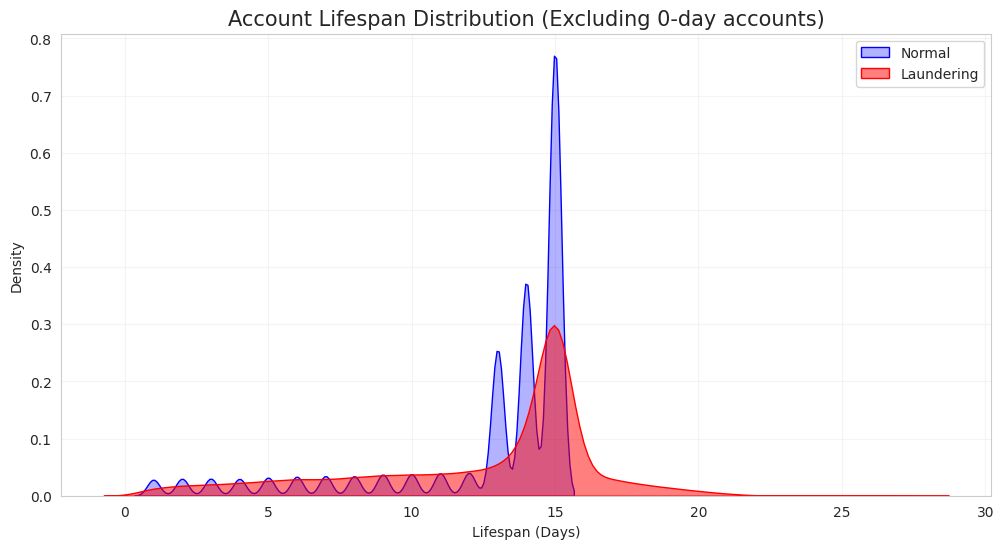

--- [수명 0일 제외 후 통계] ---
              count       mean       std  min   25%   50%   75%   max
Is_Fraud                                                             
0         1162234.0  12.696772  3.581696  1.0  13.0  14.0  15.0  15.0
1           21581.0  12.541170  4.257995  1.0  10.0  15.0  15.0  27.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수명이 0일보다 큰 계좌만 필터링
long_active_df = lifespan_df[lifespan_df["Lifespan_Days"] > 0]

print(f"전체 계좌 중 0일 초과 활동 계좌 수: {len(long_active_df)}")
print(f"그 중 사기 계좌 수: {long_active_df[long_active_df['Is_Fraud'] == 1].shape[0]}")

# 2. 시각화 (KDE Plot)
plt.figure(figsize=(12, 6))

# 사기 계좌와 정상 계좌의 수명 분포 비교 (0일 제외 버전)
sns.kdeplot(data=long_active_df[long_active_df["Is_Fraud"] == 0], x="Lifespan_Days",
            label="Normal", fill=True, color="blue", alpha=0.3)
sns.kdeplot(data=long_active_df[long_active_df["Is_Fraud"] == 1], x="Lifespan_Days",
            label="Laundering", fill=True, color="red", alpha=0.5)

plt.title("Account Lifespan Distribution (Excluding 0-day accounts)", fontsize=15)
plt.xlabel("Lifespan (Days)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# 3. 상세 통계
print("--- [수명 0일 제외 후 통계] ---")
print(long_active_df.groupby("Is_Fraud")["Lifespan_Days"].describe())

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


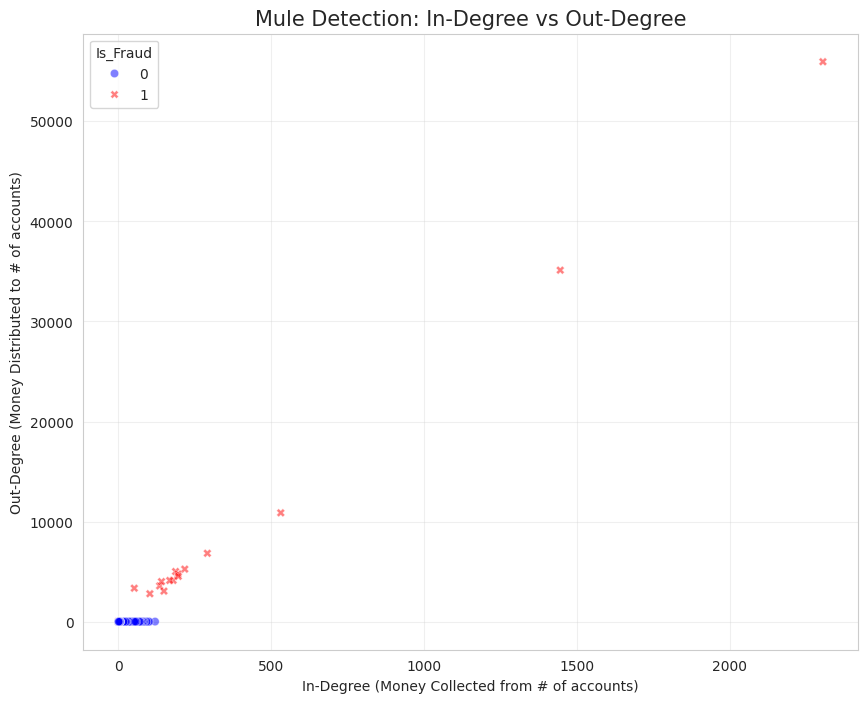

          In_Degree                                                   \
              count      mean        std  min  25%  50%  75%     max   
Is_Fraud                                                               
0         1990855.0  2.127487   2.901869  0.0  1.0  2.0  3.0   120.0   
1           22772.0  3.552213  19.084009  0.0  2.0  3.0  4.0  2304.0   

         Out_Degree                                                      
              count       mean         std  min  25%  50%  75%      max  
Is_Fraud                                                                 
0         1990855.0   2.127632    2.210611  1.0  1.0  1.0  2.0     43.0  
1           22772.0  10.589847  455.075753  1.0  2.0  3.0  4.0  55956.0  


In [ ]:
# 12. 계좌별 마당발(In) 및 쪼개기(Out) 지수 계산

# In-degree: 얼마나 많은 계좌로부터 입금을 받았는가
# Out-degree: 얼마나 많은 계좌로 송금을 보냈는가

# 1. 송금(Out) 지수 계산
out_degree = (
    df.group_by("From Account")
    .agg([
        pl.col("To Account").n_unique().alias("Out_Degree"),
        pl.col("Is Laundering").max().alias("Is_Fraud")
    ])
)

# 2. 수금(In) 지수 계산
in_degree = (
    df.group_by("To Account")
    .agg([
        pl.col("From Account").n_unique().alias("In_Degree")
    ])
)

# 3. 데이터 결합 및 시각화 준비
degree_analysis = (
    out_degree.join(in_degree, left_on="From Account", right_on="To Account", how="left")
    .fill_null(0)
    .collect()
    .to_pandas()
)

# 4. 시각화 (Scatter Plot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=degree_analysis,
    x="In_Degree",
    y="Out_Degree",
    hue="Is_Fraud",
    style="Is_Fraud",
    palette={0: "blue", 1: "red"},
    alpha=0.5
)

plt.title("Mule Detection: In-Degree vs Out-Degree", fontsize=15)
plt.xlabel("In-Degree (Money Collected from # of accounts)")
plt.ylabel("Out-Degree (Money Distributed to # of accounts)")
plt.grid(True, alpha=0.3)
plt.show()

# 사기 계좌의 평균 지수 출력
print(degree_analysis.groupby("Is_Fraud")[["In_Degree", "Out_Degree"]].describe())

--- [정상 거래 vs 사기 거래 지표 비교] ---
          fan_out_ratio  spike_ratio
Is_Fraud                            
0              0.874451     1.680290
1              1.078844     1.342611


/tmp/ipython-input-3536800954.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=degree_stats, x="Is_Fraud", y="fan_out_ratio", palette="Set2")
/tmp/ipython-input-3536800954.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=degree_stats, x="Is_Fraud", y="spike_ratio", palette="Set2")


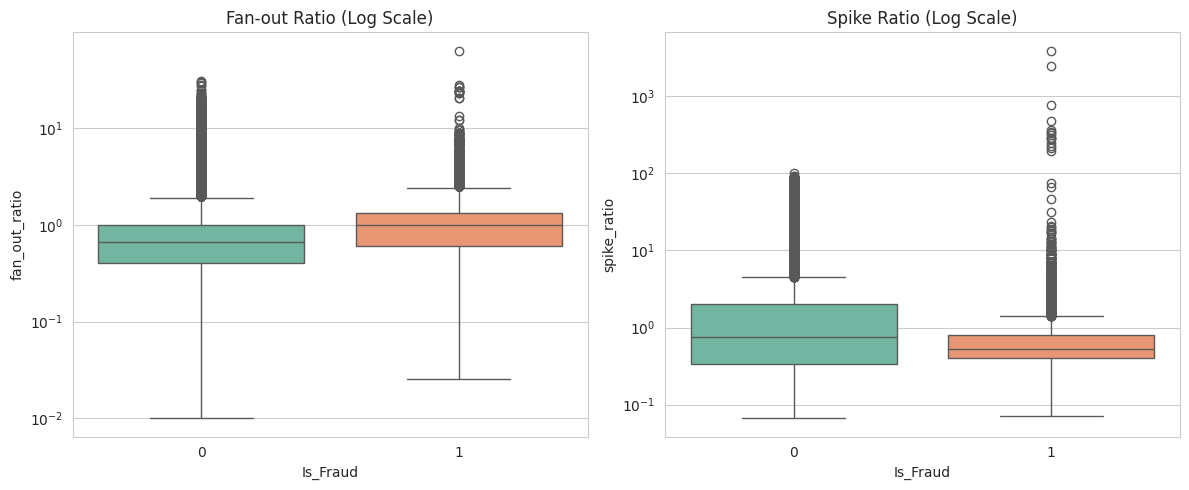

In [ ]:
# 12-2. Fan-out Ratio & Spike Ratio 계산
degree_stats = (
    degree_analysis.assign(
        # 1을 더해주는 이유는 분모가 0이 되는 것을 방지(Zero-division error)하기 위함입니다.
        fan_out_ratio = lambda x: x['Out_Degree'] / (x['In_Degree'] + 1),
        # Lifespan_Days가 0인 경우 1일로 처리하여 계산
        spike_ratio = lambda x: (x['In_Degree'] + x['Out_Degree']) / (lifespan_df.set_index('From Account').reindex(x['From Account'])['Lifespan_Days'].fillna(0).clip(lower=1).values)
    )
)

# 정상 vs 사기 비교 출력
comparison = degree_stats.groupby("Is_Fraud")[["fan_out_ratio", "spike_ratio"]].mean()

print("--- [정상 거래 vs 사기 거래 지표 비교] ---")
print(comparison)

# 시각화 (Boxplot으로 편차 확인)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=degree_stats, x="Is_Fraud", y="fan_out_ratio", palette="Set2")
plt.yscale('log') # 수치 차이가 클 수 있어 로그 스케일 적용
plt.title("Fan-out Ratio (Log Scale)")

plt.subplot(1, 2, 2)
sns.boxplot(data=degree_stats, x="Is_Fraud", y="spike_ratio", palette="Set2")
plt.yscale('log')
plt.title("Spike Ratio (Log Scale)")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 에러 수정: palette 대신 hue를 직접 지정하고, Is_Fraud를 문자열로 잠시 변환해서 확실히 구분합니다.
plot_df = ratio_df.copy()
plot_df['Is_Fraud_Str'] = plot_df['Is_Fraud'].astype(str)

plt.figure(figsize=(14, 6))

# 1. Fan-out Ratio 비교
plt.subplot(1, 2, 1)
sns.boxplot(
    data=plot_df,
    x="Is_Fraud_Str",
    y="fan_out_ratio",
    hue="Is_Fraud_Str",
    palette={"0": "blue", "1": "red"},
    legend=False
)
plt.yscale('log')
plt.title("Fan-out Ratio (Out / In)", fontsize=13)
plt.xlabel("Is Fraud (0: No, 1: Yes)")

# 2. Spike Ratio 비교
plt.subplot(1, 2, 2)
sns.boxplot(
    data=plot_df,
    x="Is_Fraud_Str",
    y="spike_ratio",
    hue="Is_Fraud_Str",
    palette={"0": "blue", "1": "red"},
    legend=False
)
plt.yscale('log')
plt.title("Spike Ratio (Activity Intensity)", fontsize=13)
plt.xlabel("Is Fraud (0: No, 1: Yes)")

plt.tight_layout()
plt.show()

NameError: name 'ratio_df' is not defined

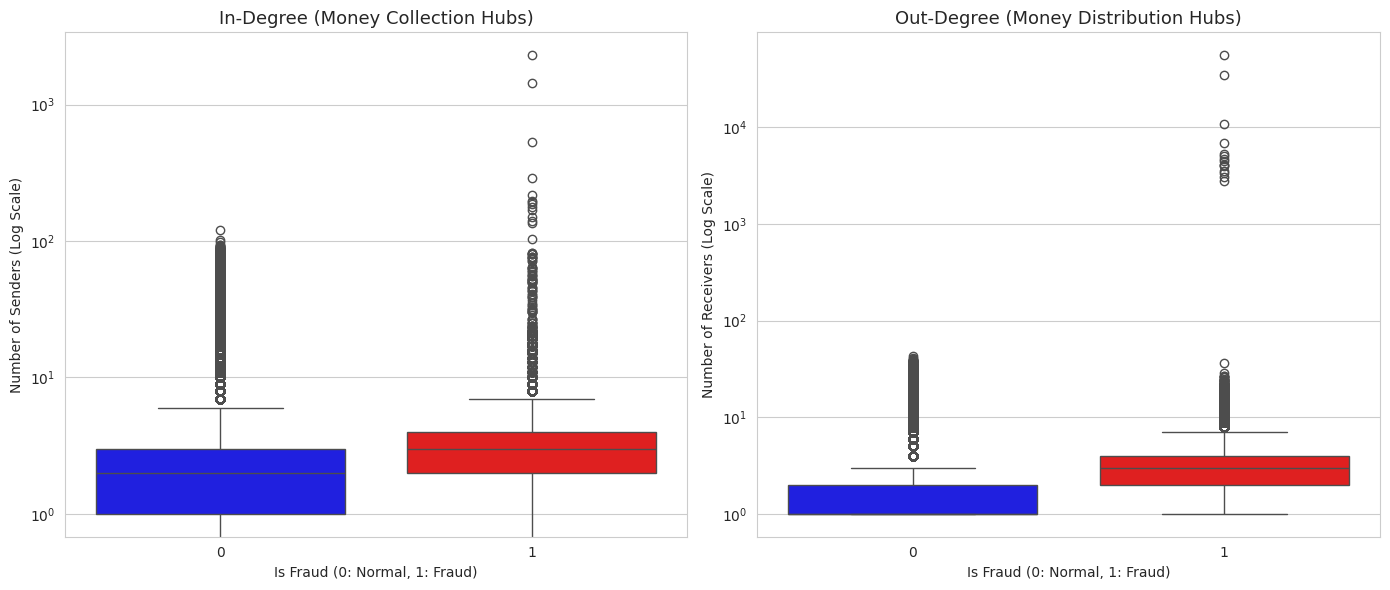

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비: Is_Fraud를 문자열로 변환 (Seaborn 시각화 에러 방지용)
plot_df = degree_analysis.copy()
plot_df['Is_Fraud_Str'] = plot_df['Is_Fraud'].astype(str)

plt.figure(figsize=(14, 6))

# 2. 마당발 지수 (In-Degree) 비교: 누가 더 많이 돈을 모으는가?
plt.subplot(1, 2, 1)
sns.boxplot(
    data=plot_df,
    x="Is_Fraud_Str",
    y="In_Degree",
    hue="Is_Fraud_Str",
    palette={"0": "blue", "1": "red"},
    legend=False
)
plt.yscale('log') # 값이 너무 커서 로그 스케일로 봐야 분포가 보입니다.
plt.title("In-Degree (Money Collection Hubs)", fontsize=13)
plt.ylabel("Number of Senders (Log Scale)")
plt.xlabel("Is Fraud (0: Normal, 1: Fraud)")

# 3. 쪼개기 지수 (Out-Degree) 비교: 누가 더 많이 돈을 뿌리는가?
plt.subplot(1, 2, 2)
sns.boxplot(
    data=plot_df,
    x="Is_Fraud_Str",
    y="Out_Degree",
    hue="Is_Fraud_Str",
    palette={"0": "blue", "1": "red"},
    legend=False
)
plt.yscale('log')
plt.title("Out-Degree (Money Distribution Hubs)", fontsize=13)
plt.ylabel("Number of Receivers (Log Scale)")
plt.xlabel("Is Fraud (0: Normal, 1: Fraud)")

plt.tight_layout()
plt.show()

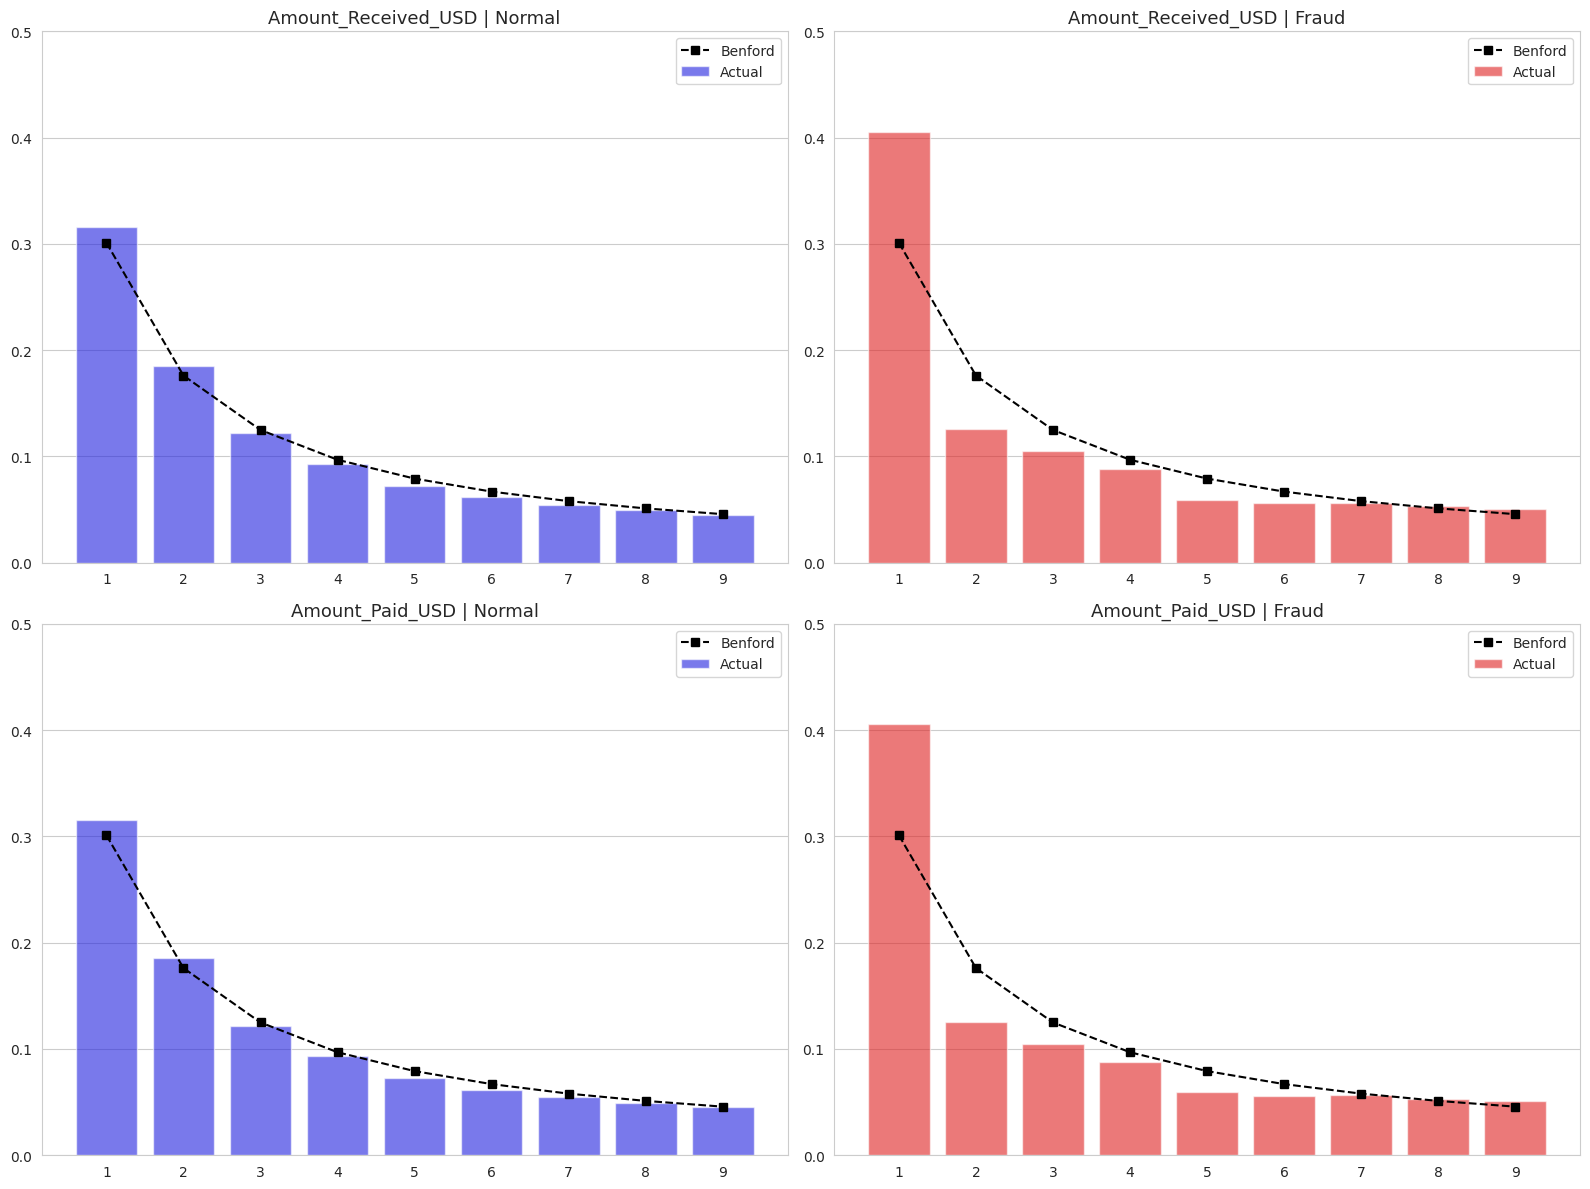

In [ ]:
#13. 벤포드의 법칙 검증 (앞자리수 분석)

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 첫째 자리 추출 함수 (USD 소수점 대응)
def get_first_digit(val):
    try:
        # 소수점 제거, 앞자리 0 제거 후 첫 숫자 추출
        s = str(val).replace('.', '').lstrip('0')
        return int(s[0]) if s and s[0] != '0' else None
    except:
        return None

# 2. USD 관련 데이터 추출
usd_cols = ["Amount_Received_USD", "Amount_Paid_USD"]
benford_data = df.select([
    pl.col(usd_cols[0]),
    pl.col(usd_cols[1]),
    pl.col("Is Laundering").alias("Is_Fraud")
]).collect()

# 3. Pandas 변환 및 분석
benford_pd = benford_data.to_pandas()
digits = np.arange(1, 10)
theoretical = np.log10(1 + 1/digits)

# 시각화 (2x2 그리드: 입금/출금 x 정상/사기)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['blue', 'red']

for row_idx, col_name in enumerate(usd_cols):
    # 첫째 자리 추출
    temp_series = benford_pd[col_name].apply(get_first_digit)

    for col_idx, is_fraud in enumerate([0, 1]):
        ax = axes[row_idx, col_idx]

        # 해당 조건의 데이터 필터링
        subset_digits = temp_series[(benford_pd['Is_Fraud'] == is_fraud)].dropna()
        counts = subset_digits.value_counts(normalize=True).sort_index()

        # 1~9까지 빈도 매핑
        plot_data = [counts.get(d, 0) for d in digits]

        # 시각화
        sns.barplot(x=digits, y=plot_data, alpha=0.6, color=colors[col_idx], ax=ax, label='Actual')
        ax.plot(np.arange(9), theoretical, marker='s', color='black', linestyle='--', label='Benford')

        status = "Fraud" if is_fraud == 1 else "Normal"
        ax.set_title(f"{col_name} | {status}", fontsize=13)
        ax.set_ylim(0, 0.5)
        ax.legend()

plt.tight_layout()
plt.show()

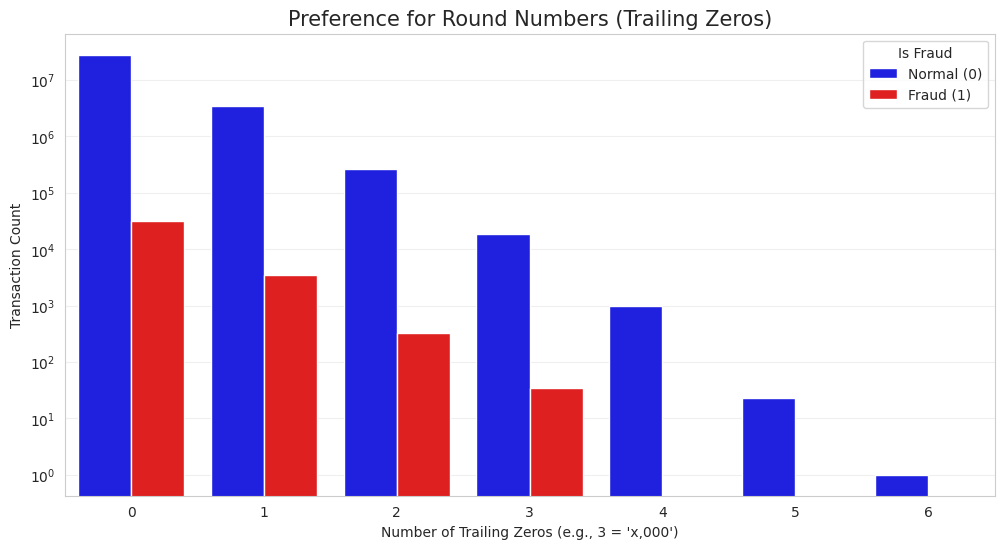

--- [뒷자리 0의 개수별 사기 비중] ---
Zero_Count
0    0.111742
1    0.098576
2    0.125528
3    0.188832
4    0.000000
5    0.000000
6    0.000000
Name: Is_Fraud, dtype: float64


In [ ]:
#14. 딱 떨어지는 금액 선호도 분석


import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 0으로 얼마나 딱 떨어지는지 계산하는 함수
# 금액을 10, 100, 1000 등으로 나누었을 때 나머지가 0인지를 봅니다.
def count_trailing_zeros(amount):
    s = str(int(amount))
    return len(s) - len(s.rstrip('0'))

# 2. 데이터 준비 (현지 통화 기준)
round_data = df.select([
    pl.col("Amount Received"),
    pl.col("Is Laundering").alias("Is_Fraud")
]).collect()

round_pd = round_data.to_pandas()
# 뒷자리 0의 개수 추출 (예: 5000 -> 3개, 1050 -> 1개)
round_pd['Zero_Count'] = round_pd['Amount Received'].apply(lambda x: count_trailing_zeros(x) if x > 0 else 0)

# 3. 시각화: 뒷자리 0의 개수별 분포 비교
plt.figure(figsize=(12, 6))

# 정상 vs 사기 비율 비교를 위해 빈도(Density)로 시각화
sns.countplot(data=round_pd, x='Zero_Count', hue='Is_Fraud', palette={0: "blue", 1: "red"})

plt.title("Preference for Round Numbers (Trailing Zeros)", fontsize=15)
plt.xlabel("Number of Trailing Zeros (e.g., 3 = 'x,000')")
plt.ylabel("Transaction Count")
plt.yscale('log') # 수치 차이가 클 수 있으므로 로그 스케일 적용
plt.legend(title='Is Fraud', labels=['Normal (0)', 'Fraud (1)'])
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. 통계치 출력
print("--- [뒷자리 0의 개수별 사기 비중] ---")
print(round_pd.groupby('Zero_Count')['Is_Fraud'].mean() * 100)

/tmp/ipython-input-4061125596.py:22: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=gap_pd[gap_pd['Gap_Percent'].between(-1, 15)],


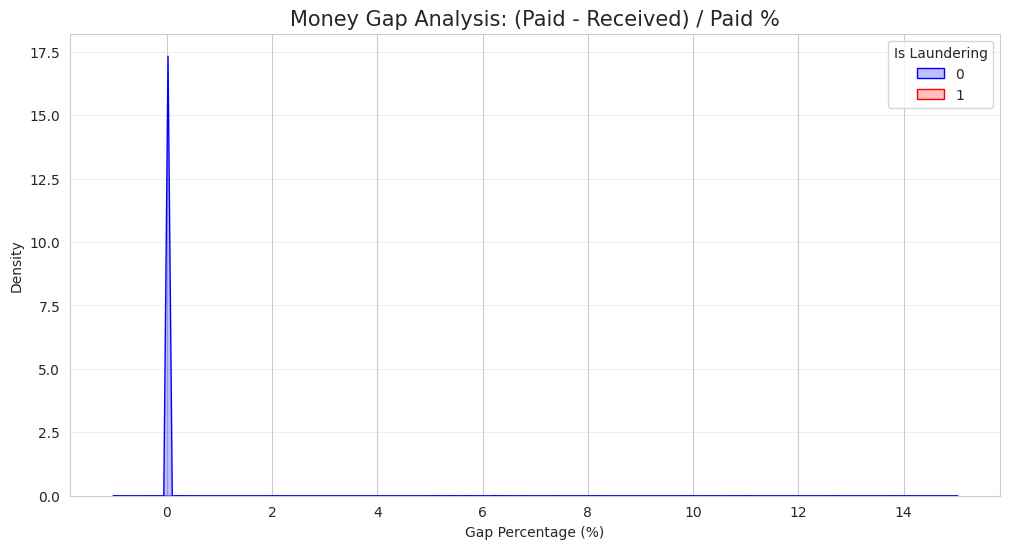

--- [사기 유무에 따른 평균 갭(USD) 및 비율(%) ] ---
Is Laundering                 0        1
Gap_USD     count  3.186344e+07  35230.0
            mean  -2.851740e+03      0.0
            std    1.046724e+07      0.0
            min   -5.010282e+10      0.0
            25%    0.000000e+00      0.0
            50%    0.000000e+00      0.0
            75%    0.000000e+00      0.0
            max    5.090163e+09      0.0
Gap_Percent count  3.186344e+07  35230.0
            mean  -4.429888e-02      0.0
            std    2.357776e+00      0.0
            min   -2.571429e+02      0.0
            25%    0.000000e+00      0.0
            50%    0.000000e+00      0.0
            75%    0.000000e+00      0.0
            max    5.951667e+01      0.0


In [ ]:
#15. 사라진 돈(Gap) 분석: Amount Paid - Amount Received

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 갭(Gap) 및 갭 비율(Gap %) 계산
# Gap = 보낸 돈 - 받은 돈 (보통 수수료나 세탁 비용으로 인해 Paid가 더 큼)
gap_df = df.with_columns([
    (pl.col("Amount_Paid_USD") - pl.col("Amount_Received_USD")).alias("Gap_USD"),
    ((pl.col("Amount_Paid_USD") - pl.col("Amount_Received_USD")) / pl.col("Amount_Paid_USD") * 100).alias("Gap_Percent")
]).select([
    "Gap_USD", "Gap_Percent", "Is Laundering"
]).collect()

gap_pd = gap_df.to_pandas()

# 2. 시각화: 정상 vs 사기 갭 비율 분포
plt.figure(figsize=(12, 6))

# 갭 비율이 너무 크거나 작은 이상치를 제외하고 메인 분포 확인 (0% ~ 10% 사이 위주)
sns.kdeplot(data=gap_pd[gap_pd['Gap_Percent'].between(-1, 15)],
            x="Gap_Percent", hue="Is Laundering", fill=True, palette={0: "blue", 1: "red"})

plt.title("Money Gap Analysis: (Paid - Received) / Paid %", fontsize=15)
plt.xlabel("Gap Percentage (%)")
plt.ylabel("Density")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. 통계 요약
print("--- [사기 유무에 따른 평균 갭(USD) 및 비율(%) ] ---")
print(gap_pd.groupby("Is Laundering")[["Gap_USD", "Gap_Percent"]].describe().T)

In [ ]:
# 통화가 같은 거래만 추출해서 현지 통화 기준으로 Gap 재계산
verification_df = df.filter(
    pl.col("Payment Currency") == pl.col("Receiving Currency")
).with_columns([
    (pl.col("Amount Paid") - pl.col("Amount Received")).alias("Local_Gap")
]).select([
    "Local_Gap", "Is Laundering"
]).collect()

v_pd = verification_df.to_pandas()
print("--- [통화가 같은 거래의 실제 차액(Local_Gap) 분포] ---")
print(v_pd.groupby("Is Laundering")["Local_Gap"].value_counts().head(10))

--- [통화가 같은 거래의 실제 차액(Local_Gap) 분포] ---
Is Laundering  Local_Gap
0              0.0          31378220
1              0.0             35230
Name: count, dtype: int64


In [ ]:
# 1. 보낸 통화와 받은 통화가 다른 행들만 필터링
diff_currency = df.filter(
    pl.col("Payment Currency") != pl.col("Receiving Currency")
).select([
    "Payment Currency",
    "Receiving Currency",
    "Is Laundering"
]).collect()

# 2. 결과 리포트
total_diff = diff_currency.height
fraud_diff = diff_currency.filter(pl.col("Is Laundering") == 1).height

print(f"--- [환전 거래 수사 리포트] ---")
print(f"전체 환전 거래 건수: {total_diff:,}건")
print(f"그 중 사기 거래 건수: {fraud_diff:,}건")

if total_diff > 0:
    print("\n--- [주요 환전 경로 Top 10] ---")
    print(diff_currency.group_by(["Payment Currency", "Receiving Currency"])
          .agg(pl.len().alias("Count"))
          .sort("Count", descending=True)
          .head(10))
else:
    print("\n[알림] 모든 거래의 보낸 통화와 받은 통화가 일치합니다. (국내 혹은 단일 통화망 거래)")

--- [환전 거래 수사 리포트] ---
전체 환전 거래 건수: 485,219건
그 중 사기 거래 건수: 0건

--- [주요 환전 경로 Top 10] ---
shape: (10, 3)
┌──────────────────┬────────────────────┬────────┐
│ Payment Currency ┆ Receiving Currency ┆ Count  │
│ ---              ┆ ---                ┆ ---    │
│ str              ┆ str                ┆ u32    │
╞══════════════════╪════════════════════╪════════╡
│ US Dollar        ┆ Euro               ┆ 104209 │
│ Euro             ┆ US Dollar          ┆ 81120  │
│ Yuan             ┆ US Dollar          ┆ 51405  │
│ US Dollar        ┆ Yuan               ┆ 30457  │
│ US Dollar        ┆ Shekel             ┆ 15152  │
│ US Dollar        ┆ UK Pound           ┆ 12588  │
│ US Dollar        ┆ Canadian Dollar    ┆ 12239  │
│ US Dollar        ┆ Ruble              ┆ 11975  │
│ US Dollar        ┆ Yen                ┆ 10965  │
│ US Dollar        ┆ Australian Dollar  ┆ 10731  │
└──────────────────┴────────────────────┴────────┘


In [ ]:
import polars as pl

# 1. 환전 거래(Payment != Receiving)만 필터링
# 2. Paid_USD와 Received_USD의 차액 계산
check_gap = df.filter(
    pl.col("Payment Currency") != pl.col("Receiving Currency")
).with_columns([
    (pl.col("Amount_Paid_USD") - pl.col("Amount_Received_USD")).alias("USD_Diff")
]).select([
    "Payment Currency",
    "Receiving Currency",
    "Amount Paid",
    "Amount Received",
    "Amount_Paid_USD",
    "Amount_Received_USD",
    "USD_Diff",
    "Is Laundering"
]).limit(20).collect() # 일단 20개만 뽑아서 눈으로 확인

# 결과 출력
import pandas as pd
pd.set_option('display.max_columns', None)
print("--- [환전 거래의 USD 차액 직접 확인] ---")
print(check_gap.to_pandas())

# 전체 환전 거래 중 차액이 0이 아닌 거래가 하나라도 있는지 통계 확인
stats = df.filter(
    pl.col("Payment Currency") != pl.col("Receiving Currency")
).select([
    (pl.col("Amount_Paid_USD") - pl.col("Amount_Received_USD")).abs().max().alias("Max_Diff"),
    (pl.col("Amount_Paid_USD") - pl.col("Amount_Received_USD")).abs().mean().alias("Mean_Diff")
]).collect()

print("\n--- [환전 거래 차액 통계] ---")
print(stats)

--- [환전 거래의 USD 차액 직접 확인] ---
   Payment Currency Receiving Currency  Amount Paid  Amount Received  \
0              Euro          US Dollar    126462.96        148187.21   
1              Euro          US Dollar    150091.05        175874.21   
2              Euro          US Dollar      2725.85          3194.10   
3              Euro          US Dollar      8449.10          9900.52   
4               Yen          US Dollar     15455.47           146.64   
5               Yen          US Dollar     14820.57           140.61   
6              Yuan          US Dollar      1244.92           185.88   
7              Yuan          US Dollar      5324.54           794.99   
8              Yuan          US Dollar      2424.49           361.99   
9              Yuan          US Dollar      1857.57           277.35   
10             Euro          US Dollar      8676.75         10167.27   
11             Euro          US Dollar      5482.43          6424.22   
12             Euro          US Do

/tmp/ipython-input-2119417948.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x="Payment Format", y="Fraud_Count", palette="Reds_r")
/tmp/ipython-input-2119417948.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf, x="Payment Format", y="Fraud_Rate_Pct", palette="magma")


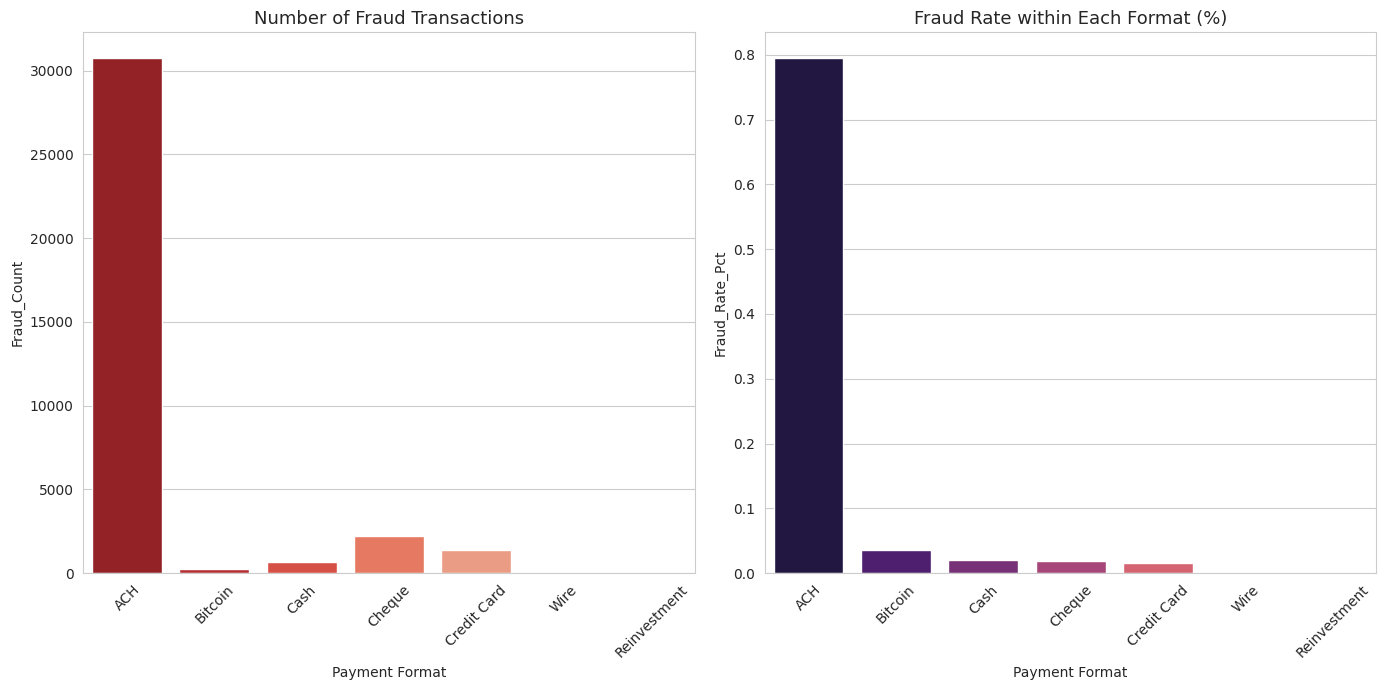

--- [결제 수단별 범죄 가담 분석 보고서] ---


Payment Format,Total_Count,Fraud_Count,Fraud_Rate_Pct
str,u32,i64,f64
"""ACH""",3868513,30746,0.794776
"""Bitcoin""",689038,244,0.035412
"""Cash""",3217537,666,0.020699
"""Cheque""",12280121,2220,0.018078
"""Credit Card""",8778042,1354,0.015425
"""Wire""",1119774,0,0.0
"""Reinvestment""",1945644,0,0.0


In [ ]:
#16. 결제 수단별 사기 금액 패턴

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 결제 수단별 통계 계산
# 전체 거래 수 대비 사기 거래의 비중을 확인합니다.
payment_stats = df.group_by("Payment Format").agg([
    pl.len().alias("Total_Count"),
    pl.col("Is Laundering").sum().alias("Fraud_Count")
]).with_columns(
    (pl.col("Fraud_Count") / pl.col("Total_Count") * 100).alias("Fraud_Rate_Pct")
).sort("Fraud_Rate_Pct", descending=True).collect()

# 2. 시각화
plt.figure(figsize=(14, 7))
pdf = payment_stats.to_pandas()

# (1) 사기 거래의 절대적인 건수 비교
plt.subplot(1, 2, 1)
sns.barplot(data=pdf, x="Payment Format", y="Fraud_Count", palette="Reds_r")
plt.title("Number of Fraud Transactions", fontsize=13)
plt.xticks(rotation=45)

# (2) 결제 수단 내에서의 사기 비율 (%)
plt.subplot(1, 2, 2)
sns.barplot(data=pdf, x="Payment Format", y="Fraud_Rate_Pct", palette="magma")
plt.title("Fraud Rate within Each Format (%)", fontsize=13)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 3. 상세 리포트 출력
print("--- [결제 수단별 범죄 가담 분석 보고서] ---")
payment_stats

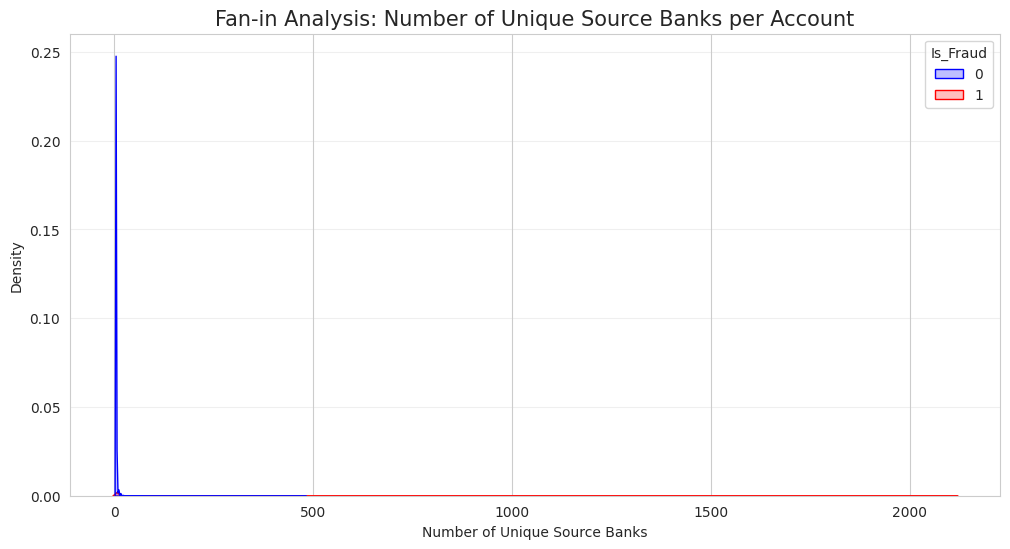

--- [위험 의심 계좌: Fan-in Top 10] ---


To Account,Unique_From_Banks,Is_Fraud
str,u32,i64
"""100428660""",2114,1
"""1004286A8""",1330,1
"""1004286F0""",482,0
"""1004289C0""",274,0
"""100428858""",207,0
"""1004288A0""",186,0
"""1004287C8""",179,1
"""100428810""",173,0
"""100428738""",165,0


In [ ]:
# 17. 거책(Mule) 탐지: 수취 계좌당 유입 은행 개수 (Fan in)

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 수취 계좌별 유입 은행(From Bank)의 고유 개수 계산
fan_in_df = df.group_by("To Account").agg([
    pl.col("From Bank").n_unique().alias("Unique_From_Banks"),
    pl.col("Is Laundering").max().alias("Is_Fraud") # 해당 계좌에 사기 이력이 한 번이라도 있는지
]).collect()

fan_in_pd = fan_in_df.to_pandas()

# 2. 시각화: 정상 vs 사기 계좌의 유입 은행 개수 분포
plt.figure(figsize=(12, 6))

# 유입 은행이 1개인 경우(정상)가 압도적이므로, 차이를 보기 위해 2개 이상인 구간 강조
sns.kdeplot(data=fan_in_pd[fan_in_pd['Unique_From_Banks'] > 1],
            x="Unique_From_Banks", hue="Is_Fraud", fill=True, palette={0: "blue", 1: "red"})

plt.title("Fan-in Analysis: Number of Unique Source Banks per Account", fontsize=15)
plt.xlabel("Number of Unique Source Banks")
plt.ylabel("Density")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. 상위 10개 위험 계좌 (가장 많은 은행으로부터 돈을 받은 계좌)
print("--- [위험 의심 계좌: Fan-in Top 10] ---")
fan_in_df.sort("Unique_From_Banks", descending=True).head(10)

🕵️ 탐지된 컬럼명: [보내는 쪽: From Account] / [받는 쪽: To Account]


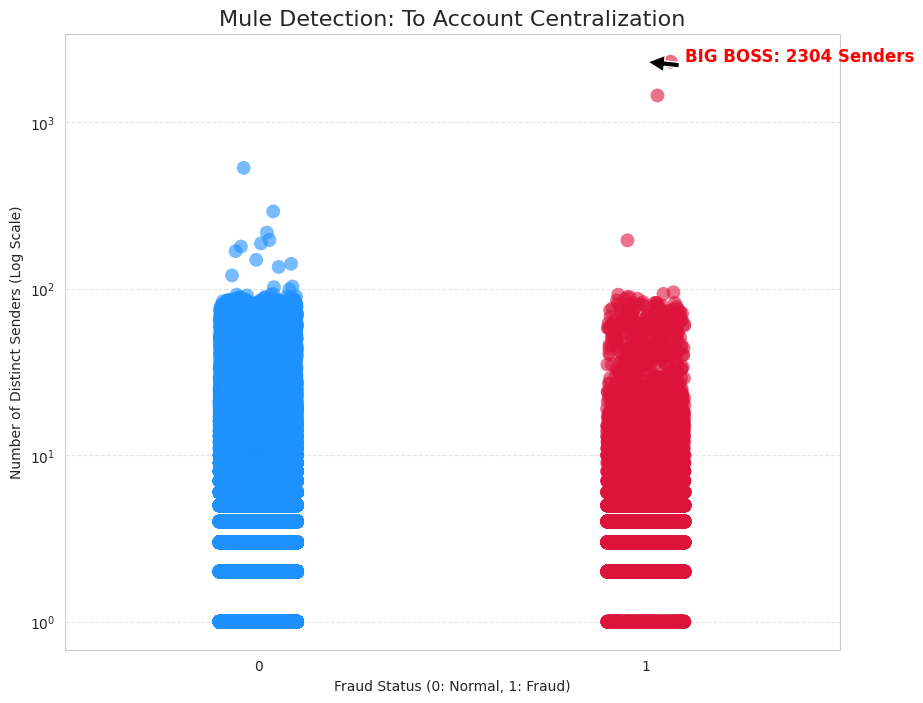

--- [수사 대상: To Account 기준 Fan-in Top 10] ---


To Account,Senders_Count,Is_Fraud
str,u32,i64
"""100428660""",2304,1
"""1004286A8""",1445,1
"""1004286F0""",531,0
"""1004289C0""",291,0
"""100428858""",217,0
"""1004288A0""",196,0
"""1004287C8""",195,1
"""100428810""",187,0
"""100428738""",179,0


In [ ]:
# 17-2. 거책(Mule) 탐지: 수취 계좌당 유입 계좌 개수 (Fan in)
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 현재 데이터프레임의 모든 컬럼명 리스트 추출
all_cols = df.collect_schema().names()

# 2. 'From'과 'Account'가 들어간 컬럼과 'To'와 'Account'가 들어간 컬럼 자동 매칭
from_col = [c for c in all_cols if 'from' in c.lower() and 'account' in c.lower()][0]
to_col = [c for c in all_cols if 'to' in c.lower() and 'account' in c.lower()][0]

print(f"🕵️ 탐지된 컬럼명: [보내는 쪽: {from_col}] / [받는 쪽: {to_col}]")

# 3. 수취 계좌(To Account)별 유입 계좌(From account) 개수 계산
fan_in_summary = df.group_by(to_col).agg([
    pl.col(from_col).n_unique().alias("Senders_Count"),
    pl.col("Is Laundering").max().alias("Is_Fraud")
]).collect()

fan_in_pd = fan_in_summary.to_pandas()

# 4. 시각화 (팔레트 이슈 완벽 차단)
plt.figure(figsize=(10, 8))
fan_in_pd['Is_Fraud'] = fan_in_pd['Is_Fraud'].astype(int)

# 2,114 수치를 로그 스케일로 시각화
sns.stripplot(data=fan_in_pd, x="Is_Fraud", y="Senders_Count",
              jitter=True, size=10, alpha=0.6,
              hue="Is_Fraud", palette={0: "dodgerblue", 1: "crimson"}, legend=False)

plt.yscale('log')
plt.title(f"Mule Detection: {to_col} Centralization", fontsize=16)
plt.xlabel("Fraud Status (0: Normal, 1: Fraud)")
plt.ylabel("Number of Distinct Senders (Log Scale)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 상위 1% '보스' 계좌 강조
max_val = fan_in_pd['Senders_Count'].max()
plt.annotate(f'BIG BOSS: {max_val} Senders',
             xy=(1, max_val), xytext=(1.1, max_val),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold', color='red')

plt.show()

# 5. 수사 대상 리스트 출력
print(f"--- [수사 대상: {to_col} 기준 Fan-in Top 10] ---")
fan_in_summary.sort("Senders_Count", descending=True).head(10)

In [ ]:
fan_in_summary.sort("Senders_Count", descending=True).head(10)

To Account,Senders_Count,Is_Fraud
str,u32,i64
"""100428660""",2304,1
"""1004286A8""",1445,1
"""1004286F0""",531,0
"""1004289C0""",291,0
"""100428858""",217,0
"""1004288A0""",196,0
"""1004287C8""",195,1
"""100428810""",187,0
"""100428738""",179,0


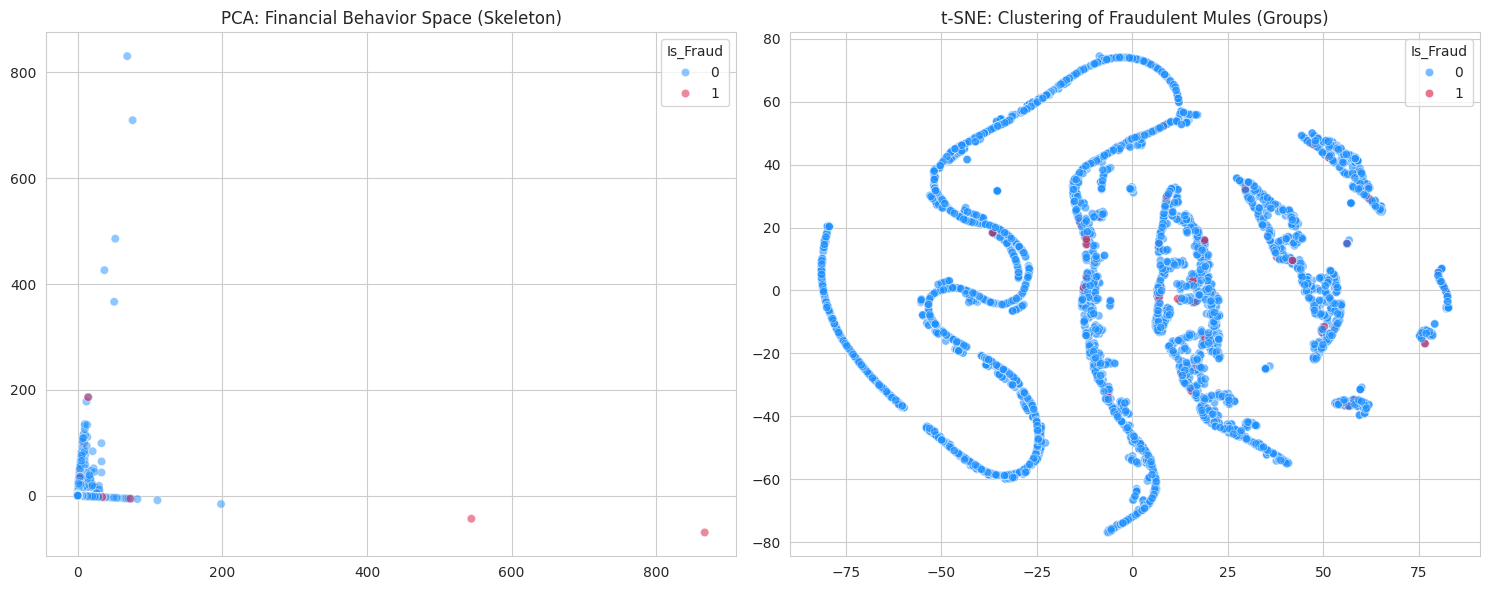

In [ ]:
#18. 데이터 공간 시각화 (PCA / t-SNE)

import polars as pl
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 다차원 특징(Feature) 생성
# 수취 계좌(To Account)별로 특징들을 모읍니다.
mule_features = df.group_by("To Account").agg([
    pl.col("Amount_Paid_USD").mean().alias("Avg_Amount"),
    pl.col("Amount_Paid_USD").max().alias("Max_Amount"),
    pl.col("From Account").n_unique().alias("Senders_Count"),
    pl.col("From Bank").n_unique().alias("Banks_Count"),
    pl.col("Is Laundering").max().alias("Is_Fraud")
]).collect().to_pandas()

# 2. 분석에 사용할 수치형 데이터만 선택 (최소 2개 이상!)
features_to_use = ["Avg_Amount", "Max_Amount", "Senders_Count", "Banks_Count"]
X = mule_features[features_to_use]
y = mule_features["Is_Fraud"]

# 3. 데이터 스케일링 (특징들 간의 단위 차이 제거)
X_scaled = StandardScaler().fit_transform(X)

# 4. PCA (데이터의 전체적인 뼈대 확인)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

# 5. t-SNE (사기꾼들의 '섬' 찾기) - 샘플링을 통해 속도 향상
# 데이터가 많으면 t-SNE가 오래 걸리므로 5,000개만 샘플링합니다.
if len(mule_features) > 5000:
    idx = np.random.choice(len(mule_features), 5000, replace=False)
    X_sample = X_scaled[idx]
    y_sample = y.iloc[idx]
else:
    X_sample = X_scaled
    y_sample = y

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(X_sample)

# 6. 시각화
plt.figure(figsize=(15, 6))

# PCA 그래프
plt.subplot(1, 2, 1)
sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], hue=y,
                palette={0: "dodgerblue", 1: "crimson"}, alpha=0.5)
plt.title("PCA: Financial Behavior Space (Skeleton)")

# t-SNE 그래프
plt.subplot(1, 2, 2)
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=y_sample,
                palette={0: "dodgerblue", 1: "crimson"}, alpha=0.6)
plt.title("t-SNE: Clustering of Fraudulent Mules (Groups)")

plt.tight_layout()
plt.show()

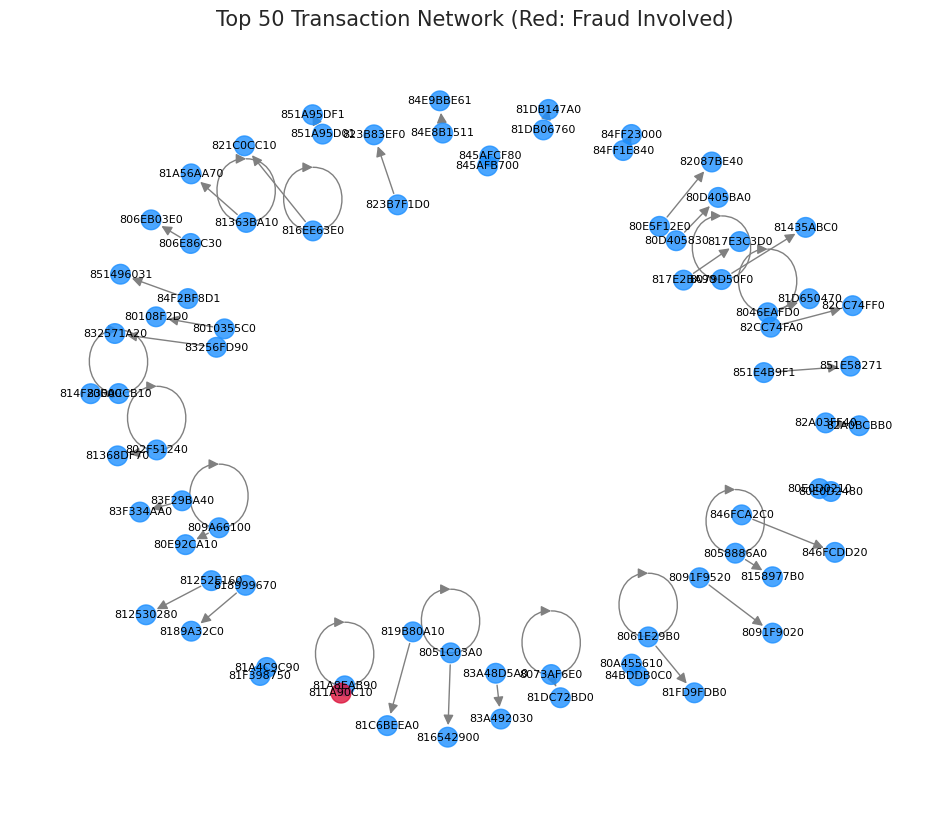

In [ ]:
#19. 자금 세탁 네트워크 구조 시각화 (Top 50)
# 거래량이 가장 많은 상위 50개 관계 추출

import polars as pl
import networkx as nx
import matplotlib.pyplot as plt

# 1. 거래량이 가장 많은 상위 50개 관계 추출 (Top 50 Network)
top_flows = df.group_by(["From Account", "To Account"]).agg([
    pl.col("Amount_Paid_USD").sum().alias("Total_Amount"),
    pl.col("Is Laundering").max().alias("Is_Fraud")
]).sort("Total_Amount", descending=True).head(50).collect()

# 2. 그래프 객체 생성
G = nx.DiGraph() # 방향성이 있는 그래프

for row in top_flows.to_dicts():
    G.add_edge(row["From Account"], row["To Account"], weight=row["Total_Amount"])

# 3. 노드 색상 결정 (사기 계좌는 빨간색, 정상은 하늘색)
# 여기선 간편하게 수취 계좌(To Account) 기준으로 사기 여부를 매핑합니다.
fraud_accounts = top_flows.filter(pl.col("Is_Fraud") == 1)["To Account"].unique().to_list()
node_colors = ["crimson" if node in fraud_accounts else "dodgerblue" for node in G.nodes()]

# 4. 시각화 (Spring Layout으로 관계도 배치)
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5, seed=42) # 노드 간 거리를 적절히 배치

# 노드와 간선 그리기
nx.draw_networkx_nodes(G, pos, node_size=200, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, width=1, edge_color="gray", arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=8, font_family="sans-serif")

plt.title("Top 50 Transaction Network (Red: Fraud Involved)", fontsize=15)
plt.axis("off")
plt.show()

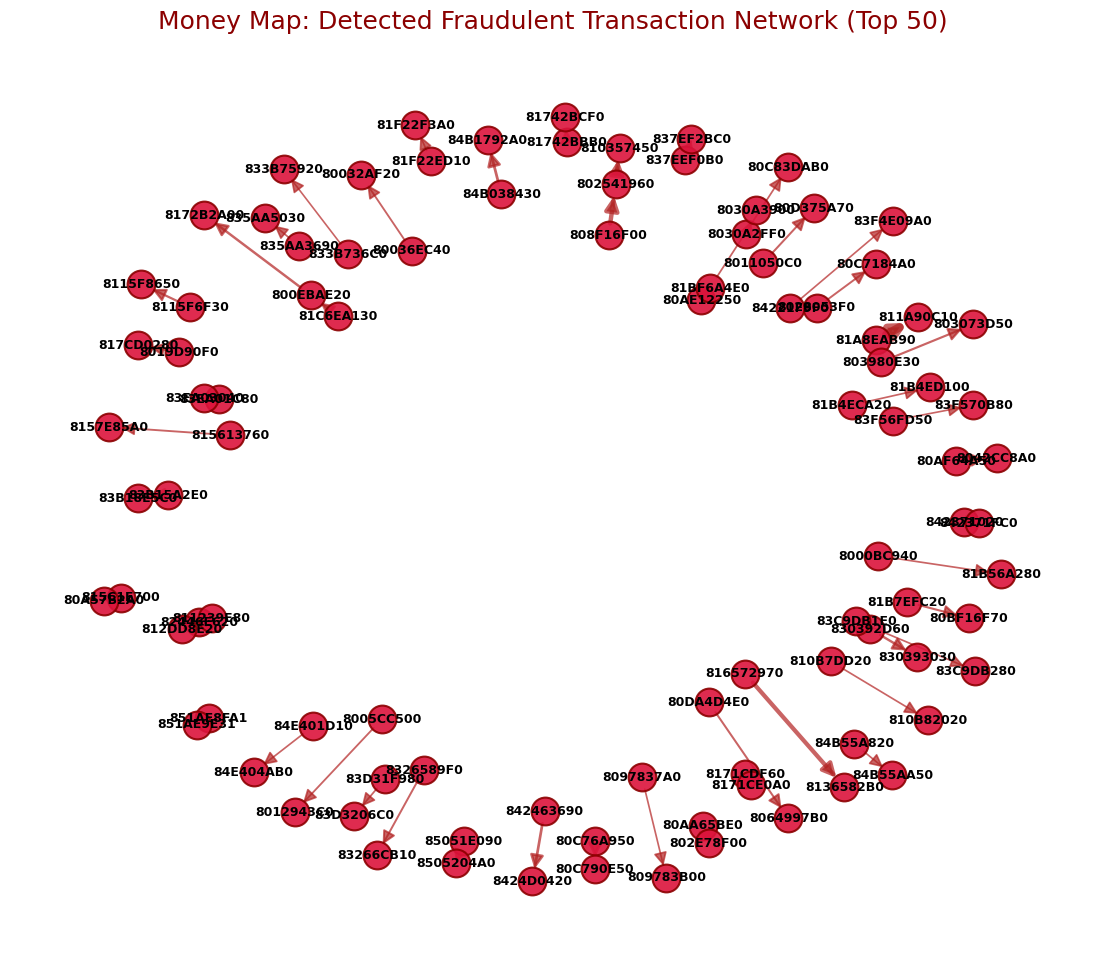


--- [범죄 조직 자금 흐름 TOP 10 (사기 거래만)] ---
  From Account To Account  Total_Amount
0    81A8EAB90  811A90C10  1.541375e+10
1    802541960  810357450  6.742080e+09
2    808F16F00  802541960  6.742080e+09
3    816572970  8136582B0  6.343891e+09
4    83B15A2E0  83B18E5C0  4.655592e+09
5    80C76A950  80C790E50  3.566430e+09
6    84B038430  84B1792A0  3.081581e+09
7    842463690  8424D0420  2.905005e+09
8    800EBAE20  8172B2A00  2.398801e+09
9    81C6EA130  800EBAE20  2.296892e+09


In [ ]:
#19-2 거래량이 가장 많은 사기 거래 상위 50개 관계 추출

import polars as pl
import networkx as nx
import matplotlib.pyplot as plt

# 1. 'Is Laundering == 1' 인 사기 거래만 필터링 (핵심! 범죄자들만 따로 추출)
fraud_transactions = df.filter(pl.col("Is Laundering") == 1).collect()

# 2. 사기 거래 내의 'From Account'와 'To Account' 관계만 추출
# 거래량 기준으로 상위 50개의 사기 관계만 시각화합니다.
# 만약 사기 거래 자체가 50개 미만이면 전체를 다 보여줍니다.
if fraud_transactions.height > 0:
    top_fraud_flows = fraud_transactions.group_by(["From Account", "To Account"]).agg([
        pl.col("Amount_Paid_USD").sum().alias("Total_Amount")
    ]).sort("Total_Amount", descending=True).head(50).to_pandas()
else:
    print("🚨 경고: Is Laundering == 1 인 사기 거래가 없습니다. 네트워크를 그릴 수 없습니다.")
    top_fraud_flows = pd.DataFrame(columns=["From Account", "To Account", "Total_Amount"])


# 3. 네트워크 그래프 객체 생성
G_fraud = nx.DiGraph()

if not top_fraud_flows.empty:
    for _, row in top_fraud_flows.iterrows():
        # 금액에 따라 간선의 두께를 조절해서 돈의 흐름 규모를 시각화합니다.
        G_fraud.add_edge(row["From Account"], row["To Account"],
                         weight=row["Total_Amount"],
                         label=f"${row['Total_Amount']:.0f}")

    # 4. 노드와 엣지 시각화
    plt.figure(figsize=(14, 12))
    pos = nx.spring_layout(G_fraud, k=0.7, iterations=50, seed=42) # 레이아웃 최적화

    # 노드 (계좌) 그리기 - 사기 계좌만 있으므로 모두 빨간색
    nx.draw_networkx_nodes(G_fraud, pos, node_size=400, node_color="crimson", alpha=0.9, linewidths=1.5, edgecolors='darkred')

    # 간선 (거래) 그리기 - 금액이 클수록 두껍게
    edge_widths = [d['weight'] / top_fraud_flows['Total_Amount'].max() * 5 + 1 for u, v, d in G_fraud.edges(data=True)] # 스케일링
    nx.draw_networkx_edges(G_fraud, pos, width=edge_widths, edge_color="firebrick", alpha=0.7, arrowsize=20)

    # 라벨 (계좌 번호) 그리기
    nx.draw_networkx_labels(G_fraud, pos, font_size=9, font_weight='bold', font_color='black')

    # 간선 라벨 (거래 금액) 그리기 - 가장 큰 거래만 표시
    # edge_labels = nx.get_edge_attributes(G_fraud, 'label')
    # nx.draw_networkx_edge_labels(G_fraud, pos, edge_labels=edge_labels, font_size=7, bbox={"boxstyle": "round,pad=0.1", "fc": "yellow", "ec": "black", "lw": 0.5, "alpha": 0.5})


    plt.title("Money Map: Detected Fraudulent Transaction Network (Top 50)", fontsize=18, color='darkred')
    plt.axis("off") # 축 표시 제거
    plt.show()

else:
    print("사기 거래 데이터가 없어 '자금 이동 경로'를 시각화할 수 없습니다. 데이터를 확인해 주세요.")

# 5. 사기 거래 TOP 10 확인 (데이터 테이블)
print("\n--- [범죄 조직 자금 흐름 TOP 10 (사기 거래만)] ---")
if fraud_transactions.height > 0:
    fraud_flow_summary = fraud_transactions.group_by(["From Account", "To Account"]).agg([
        pl.col("Amount_Paid_USD").sum().alias("Total_Amount")
    ]).sort("Total_Amount", descending=True).head(10).to_pandas()
    print(fraud_flow_summary)
else:
    print("사기 거래 데이터가 없습니다.")

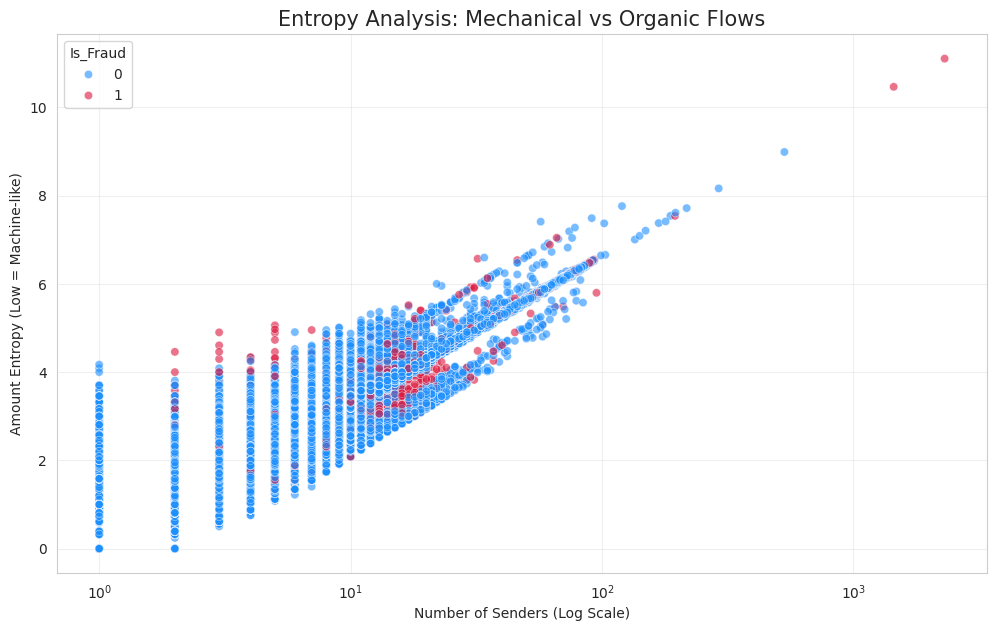

--- [수사 보고: 기계적 세탁 의심 계좌 Top 10] ---


,To Account,Senders_Count,Amount_Entropy,Is_Fraud
962345,841E8D650,1,-1.442823e-12,0
24056,850662150,1,-1.442823e-12,0
931718,82CF03D60,1,-1.442823e-12,0
931682,805BBDA10,1,-1.442823e-12,0
1205085,84AF55E61,1,-1.442823e-12,0
962384,8412F08D0,1,-1.442823e-12,0
962383,833EF9FA0,1,-1.442823e-12,0
1322263,8372D9820,1,-1.442823e-12,0
1680289,814D62591,1,-1.442823e-12,0
931565,835215FC0,1,-1.442823e-12,0


In [ ]:
# 20. 거래 금액 엔트로피 분석

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 엔트로피 계산 함수 (데이터가 들어오면 섀넌 엔트로피 반환)
def calculate_entropy(series):
    # 폴라즈 시리즈를 넘파이로 변환
    amounts = series.to_numpy()
    if len(amounts) <= 1:
        return 0.0
    # 금액별 빈도수 계산
    _, counts = np.unique(amounts, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-12)) # 0 로그 방지용 미세값 추가

# 2. To Account별로 금액 엔트로피 계산
# .map_elements()를 사용하여 각 그룹의 리스트에 함수를 적용합니다.
entropy_analysis = df.group_by("To Account").agg([
    pl.col("Amount_Paid_USD").alias("amount_list"),
    pl.col("From Account").n_unique().alias("Senders_Count"),
    pl.col("Is Laundering").max().alias("Is_Fraud")
]).collect()

# 리스트 데이터에 엔트로피 함수 적용
entropy_pd = entropy_analysis.with_columns(
    pl.col("amount_list").map_elements(calculate_entropy, return_dtype=pl.Float64).alias("Amount_Entropy")
).to_pandas()

# 3. 시각화
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=entropy_pd,
    x="Senders_Count",
    y="Amount_Entropy",
    hue="Is_Fraud",
    palette={0: "dodgerblue", 1: "crimson"},
    alpha=0.6
)

plt.xscale('log')
plt.title("Entropy Analysis: Mechanical vs Organic Flows", fontsize=15)
plt.xlabel("Number of Senders (Log Scale)")
plt.ylabel("Amount Entropy (Low = Machine-like)")
plt.grid(True, alpha=0.3)
plt.show()

# 4. 상위 의심 계좌 출력
print("--- [수사 보고: 기계적 세탁 의심 계좌 Top 10] ---")
entropy_pd.sort_values("Amount_Entropy").head(10)[["To Account", "Senders_Count", "Amount_Entropy", "Is_Fraud"]]

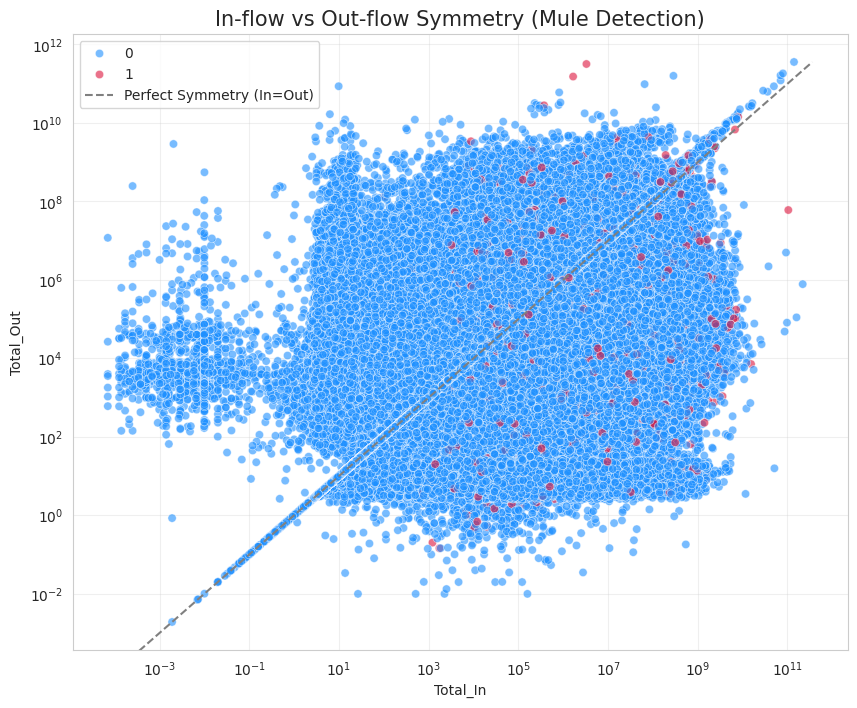

--- [수사 보고: 입출금 대칭성 상위 의심 계좌] ---
           Account      Total_In     Total_Out  Out_In_Ratio  Is Laundering
484136   802541960  6.742083e+09  6.794912e+09      1.007836              1
244998   8508EBB61  2.506472e+09  2.506342e+09      0.999948              0
608890   84DAD2141  1.879111e+09  1.844894e+09      0.981791              0
1440595  84E612D11  1.719963e+09  1.720572e+09      1.000354              0
389107   84F195531  1.688180e+09  1.688174e+09      0.999997              0
1310862  800109040  1.437770e+09  1.439285e+09      1.001054              0
373611   84F025611  1.418067e+09  1.417939e+09      0.999909              0
874976   84DAD1C41  1.325804e+09  1.325910e+09      1.000080              0
516170   84EFD9E21  1.320098e+09  1.320404e+09      1.000232              0
1578312  8000DB390  1.126298e+09  1.126748e+09      1.000400              0


In [ ]:
# 21. 입금(In) vs 출금(Out) 대칭성 분석 (Mule 패턴)

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 계좌별 입금(In)과 출금(Out) 데이터 집계
# From Account로 등장하면 출금(Out), To Account로 등장하면 입금(In)입니다.
in_flow = df.group_by("To Account").agg([
    pl.col("Amount_Paid_USD").sum().alias("Total_In"),
    pl.col("Timestamp").count().alias("In_Count")
]).rename({"To Account": "Account"})

out_flow = df.group_by("From Account").agg([
    pl.col("Amount_Paid_USD").sum().alias("Total_Out"),
    pl.col("Timestamp").count().alias("Out_Count")
]).rename({"From Account": "Account"})

# 2. 입출금 데이터 결합 및 대칭성 지표 생성
mule_analysis = in_flow.join(out_flow, on="Account", how="inner").with_columns([
    # 잔류율(Retention): 0에 가까울수록 들어온 돈을 다 뺀 '세탁 계좌'
    (pl.col("Total_In") - pl.col("Total_Out")).abs().alias("Diff_Amount"),
    (pl.col("Total_Out") / pl.col("Total_In")).alias("Out_In_Ratio")
]).collect().to_pandas()

# 사기 여부 매핑 (기존 df에서 가져옴)
fraud_labels = df.select(["To Account", "Is Laundering"]).group_by("To Account").agg(pl.col("Is Laundering").max()).collect().to_pandas()
mule_analysis = mule_analysis.merge(fraud_labels, left_on="Account", right_on="To Account", how="left")

# 3. 시각화: 입금액 vs 출금액 (대각선에 붙을수록 빼박 세탁)
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=mule_analysis,
    x="Total_In",
    y="Total_Out",
    hue="Is Laundering",
    palette={0: "dodgerblue", 1: "crimson"},
    alpha=0.6
)

# 완벽한 대칭선 (In = Out)
max_val = max(mule_analysis["Total_In"].max(), mule_analysis["Total_Out"].max())
plt.plot([0, max_val], [0, max_val], color='gray', linestyle='--', label='Perfect Symmetry (In=Out)')

plt.xscale('log')
plt.yscale('log')
plt.title("In-flow vs Out-flow Symmetry (Mule Detection)", fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. 검거 리스트 (입출금 비율이 99% 이상 일치하는 의심 계좌)
print("--- [수사 보고: 입출금 대칭성 상위 의심 계좌] ---")
suspicious_mules = mule_analysis[
    (mule_analysis["Out_In_Ratio"] > 0.98) & (mule_analysis["Out_In_Ratio"] < 1.02)
].sort_values("Total_In", ascending=False).head(10)
print(suspicious_mules[["Account", "Total_In", "Total_Out", "Out_In_Ratio", "Is Laundering"]])

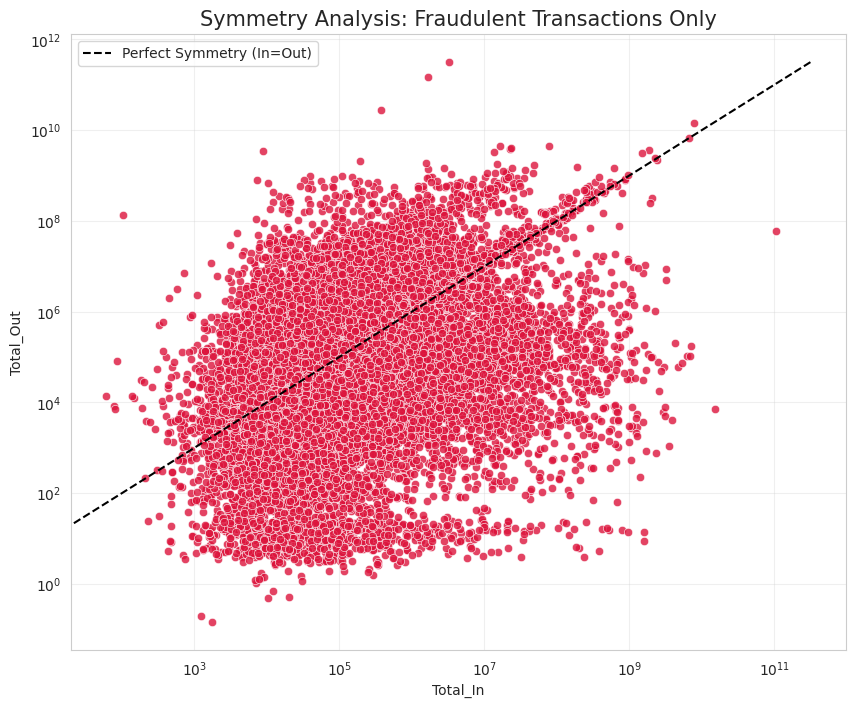

--- [수사 보고: 사기 확정 계좌 중 입출금 대칭성 상위 리스트] ---
           Account      Total_In     Total_Out  Out_In_Ratio
1171475  802541960  6.742083e+09  6.794912e+09      1.007836
81715    8002786E0  2.695769e+08  2.695869e+08      1.000037
394374   80D433200  2.623976e+08  2.608033e+08      0.993924
550647   829E96510  2.569954e+08  2.565992e+08      0.998458
1527338  81B3A8CC0  1.643597e+08  1.643612e+08      1.000009
981495   811C84650  1.378967e+08  1.378775e+08      0.999861
1543930  800CC8AA0  1.204768e+08  1.213109e+08      1.006923
1014091  802F695A0  1.042728e+08  1.055896e+08      1.012629
1358422  814A3A280  9.420431e+07  9.415730e+07      0.999501
787576   815260180  6.710614e+07  6.710952e+07      1.000050


In [ ]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 계좌별 입금(In)과 출금(Out) 데이터 집계
in_flow = df.group_by("To Account").agg([
    pl.col("Amount_Paid_USD").sum().alias("Total_In"),
    pl.col("Timestamp").count().alias("In_Count")
]).rename({"To Account": "Account"})

out_flow = df.group_by("From Account").agg([
    pl.col("Amount_Paid_USD").sum().alias("Total_Out"),
    pl.col("Timestamp").count().alias("Out_Count")
]).rename({"From Account": "Account"})

# 2. 입출금 데이터 결합 및 대칭성 지표 생성
mule_analysis = in_flow.join(out_flow, on="Account", how="inner").with_columns([
    (pl.col("Total_In") - pl.col("Total_Out")).abs().alias("Diff_Amount"),
    (pl.col("Total_Out") / pl.col("Total_In")).alias("Out_In_Ratio")
]).collect().to_pandas()

# 사기 여부 매핑
fraud_labels = df.select(["To Account", "Is Laundering"]).group_by("To Account").agg(pl.col("Is Laundering").max()).collect().to_pandas()
mule_analysis = mule_analysis.merge(fraud_labels, left_on="Account", right_on="To Account", how="left")

# --- [여기서부터 말씀하신 '사기 거래만 추출' 구간] ---
# Is Laundering이 1인 데이터만 필터링
fraud_only_mule = mule_analysis[mule_analysis["Is Laundering"] == 1]

# 3. 시각화: 사기 거래의 입금액 vs 출금액
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=fraud_only_mule, # 사기 데이터만 투입!
    x="Total_In",
    y="Total_Out",
    color="crimson", # 사기니까 강렬한 빨간색
    alpha=0.8
)

# 완벽한 대칭선 (In = Out)
max_val = max(fraud_only_mule["Total_In"].max(), fraud_only_mule["Total_Out"].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', label='Perfect Symmetry (In=Out)')

plt.xscale('log')
plt.yscale('log')
plt.title("Symmetry Analysis: Fraudulent Transactions Only", fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. 사기 거래 중 입출금 비율이 99% 이상 일치하는 'A급 세탁범' 리스트
print("--- [수사 보고: 사기 확정 계좌 중 입출금 대칭성 상위 리스트] ---")
top_fraud_mules = fraud_only_mule[
    (fraud_only_mule["Out_In_Ratio"] > 0.98) & (fraud_only_mule["Out_In_Ratio"] < 1.02)
].sort_values("Total_In", ascending=False).head(10)

print(top_fraud_mules[["Account", "Total_In", "Total_Out", "Out_In_Ratio"]])